<center>

<h2>Phase 1: Data Exploration & Preprocessing</h2>

<p><b>Phishing URL Detection Project</b></p>

<p>
This notebook presents the data exploration and preprocessing phase for the phishing URL detection project.
</p>

<p>
The goal is to understand, clean, and prepare the
<b>PhiUSIIL Phishing URL Dataset</b> for supervised machine learning modeling.
</p>

<br>

<h2>Notebook Overview</h2>

<table>
<tr>
<th>No.</th>
<th>Section</th>
</tr>

<tr><td>1</td><td>Introduction</td></tr>
<tr><td>2</td><td>Problem Statement</td></tr>
<tr><td>3</td><td>Dataset Selection & Justification</td></tr>
<tr><td>4</td><td>Initial Data Inspection</td></tr>
<tr><td>5</td><td>Exploratory Data Analysis (EDA)</td></tr>
<tr><td>6</td><td>Preprocessing Pipeline</td></tr>
<tr><td>7</td><td>Preprocessed Dataset Ready for Modeling</td></tr>
<tr><td>8</td><td>Key Insights and Challenges</td></tr>
</table>

</center>

# 1. Introduction

Cybersecurity has become increasingly important as online services, digital communication, and electronic transactions continue to grow. Individuals and organizations rely heavily on internet-based platforms for activities such as banking, communication, and information sharing. As a result, protecting users and systems from cyber threats has become a critical challenge for maintaining trust and security in the digital environment.

Among the many types of cyber threats, phishing attacks are one of the most common and harmful. Phishing typically involves fraudulent messages or websites that imitate trusted services in order to trick users into revealing sensitive information such as passwords, financial data, or personal credentials. Because these malicious websites are often designed to closely resemble legitimate ones, users frequently struggle to identify them, which makes phishing a persistent and evolving cybersecurity threat.

# 2. Problem Statement

The core problem addressed in this project is the difficulty of reliably distinguishing phishing webpages from legitimate ones. Attackers increasingly design phishing sites that mimic the appearance and structure of genuine websites, making manual detection difficult for users and even for traditional rule-based security systems. As phishing techniques continue to evolve, identifying reliable patterns that differentiate malicious webpages from legitimate ones remains a significant challenge in cybersecurity.

# 3. Dataset Selection & Justification

### 3.1 Dataset Goal & Source

* Dataset goal:

  The PhiUSIIL Phishing URL Dataset is intended to support supervised phishing detection by providing labeled examples of legitimate and phishing URLs. Each sample includes engineered features extracted from both the URL and the webpage source code, capturing structural and content-based patterns that can be learned by classification models. The dataset also includes derived signals computed from existing attributes (e.g., CharContinuationRate, URLTitleMatchScore, URLCharProb, and TLDLegitimateProb), which extend the feature set for analysis and modeling.

* Source(UCI Machine Learning Repository):

      PhiUSIIL Phishing URL Dataset (2024): https://archive.ics.uci.edu/dataset/967/phiusiil%2Bphishing%2Burl%2Bdataset

### 3.2 Justification for Selection

*   Relevance:

     The dataset is relevant to our project because it focuses on the same cybersecurity problem described in our problem statement: telling phishing webpages apart from legitimate ones. It provides labeled samples and includes features extracted from both the URL and the webpage source code, which represent patterns that attackers often manipulate in phishing pages. Since the features are already extracted and organized in a structured form, we can work directly with meaningful signals instead of building a full feature-extraction process from scratch.

*   Completeness:

    The dataset provides a large set of labeled samples and a broad feature set (54 engineered features) that covers different aspects of a webpage, including URL structure and source-code based characteristics. The feature set includes both base features and derived signals computed from existing attributes, which adds extra coverage by capturing additional patterns without relying on only one type of indicator. In addition, the dataset documentation reports that there are no missing values, so the feature matrix is complete and does not require missing-value filling.

* Quality:

    The dataset is published on the UCI Machine Learning Repository, which is a widely used academic source for machine learning datasets. It is provided in a clear tabular format with engineered and derived features computed from URL and webpage attributes. This makes the dataset easy to access, inspect, and use consistently during analysis and modeling.



# 4. Initial Data Inspection

In this section, we perform an initial examination of the dataset before any analysis or preprocessing. The goal is to understand the basic structure of the data, how many samples and features it contains, what data types are present, whether any values are missing, and whether any rows are duplicated. These checks are a necessary first step because issues such as missing values or duplicate rows can silently distort all downstream analysis and model training if left unaddressed. The findings here also directly inform the preprocessing decisions made in Section 6.

### 4.1 Imports

In [45]:
# Data manipulation libraries
import pandas as pd   # used for handling datasets (DataFrames)
import numpy as np   # used for numerical operations

# Visualization libraries
import matplotlib.pyplot as plt  # basic plotting library
import seaborn as sns   # advanced statistical visualization

from IPython.display import display   # used for rendering formatted tables in notebook output

from sklearn.ensemble import RandomForestClassifier    # used to compute feature importance scores for ranking features

# Libraries used later for preprocessing
from sklearn.preprocessing import MinMaxScaler    # Feature scaling (Min-Max normalization)
from sklearn.model_selection import train_test_split   # Stratified splitting
from sklearn.feature_selection import VarianceThreshold   # Low-variance feature removal

import joblib   # used for saving fitted preprocessing objects (e.g., scaler) to disk

We import the main libraries required for data analysis and visualization. Pandas is used for loading and manipulating tabular data (data stored in rows and columns). NumPy provides support for mathematical operations on arrays of numbers. Matplotlib and Seaborn are visualization libraries that allow us to create charts, plots, and graphs to understand data visually. MinMaxScaler from scikit-learn is a preprocessing tool that rescales each feature to a fixed range between 0 and 1, which is the normalization method used in recent PhiUSIIL-based phishing detection research. train_test_split is a function that divides the dataset into a training portion and a testing portion. VarianceThreshold is a feature selector that removes features whose variance falls below a given threshold, helping eliminate near-constant features that carry no predictive value.

### 4.2 Load Dataset

In [46]:
"""
Load dataset from UCI ML Repository

Purpose:
- Fetch the PhiUSIIL Phishing URL dataset directly from the UCI ML Repository.
- Separates features (X) and target (y) immediately so the notebook uses
  the standard X / y convention throughout.

Inputs:
- UCI dataset ID 967.

Outputs:
- X: DataFrame containing all 54 feature columns.
- y: Series containing the binary target label (0 = phishing, 1 = legitimate).
- target_column: string name of the target column, used in downstream cells.
"""

# 1) Install UCI loader
!pip install ucimlrepo -q

from ucimlrepo import fetch_ucirepo

# 2) Fetch dataset (ID 967 = PhiUSIIL Phishing URL Dataset)
ds = fetch_ucirepo(id=967)

# 3) Separate features and target
X = ds.data.features.copy()
y = ds.data.targets.squeeze()

# 4) Store target column name for reuse
target_column = "label"

print("Dataset loaded successfully.")
print("Features shape:", X.shape)
print("Target shape:  ", y.shape)
print("Classes:", y.unique())


Dataset loaded successfully.
Features shape: (235795, 54)
Target shape:   (235795,)
Classes: [1 0]


We use the ucimlrepo library to fetch the PhiUSIIL Phishing URL dataset directly from the UCI Machine Learning Repository using its dataset ID (967). Loading this way is preferred over a local file because it is fully reproducible, which means anyone running this notebook will pull the exact same dataset from the official source without needing to download or share a file manually.

The library returns the dataset as an object. We extract features into X (a DataFrame of 235,795 rows and 54 columns) and the target into y (a 1-D Series of the same length). We ensure y is always a Series rather than a DataFrame since some versions of the library return it as a single-column DataFrame, which would cause errors in downstream steps. The target column name label is stored separately so it can be referenced consistently throughout the notebook without hardcoding the string repeatedly.

### 4.3 Dataset Overview

In [47]:
"""
Dataset metadata summary table

Purpose:
- Extract key metadata information about the dataset and present it in a
  clean summary table for quick reference during exploratory data analysis.

Inputs:
- ds: dataset object retrieved from the UCI ML Repository containing
  metadata about the dataset.

Outputs:
- metadata_table: a formatted table displaying core dataset attributes
  such as dataset name, number of instances, number of features,
  feature types, target column, and dataset creation/update details.
"""



# 1) Access metadata stored in the dataset object
meta = ds.metadata

# 2) Create a structured table summarizing key dataset attributes
metadata_table = pd.DataFrame({
    "Attribute": [
        "Dataset Name",
        "Number of Instances",
        "Number of Features",
        "Feature Types",
        "Target Column",
        "Has Missing Values",
        "Year Created",
        "Last Updated"
    ],
    "Value": [
        meta["name"],
        meta["num_instances"],
        meta["num_features"],
        ", ".join(meta["feature_types"]),
        ", ".join(meta["target_col"]),
        meta["has_missing_values"],
        meta["year_of_dataset_creation"],
        meta["last_updated"]
    ]
})

# 3) Display the metadata table without showing the index column
metadata_table.style.hide(axis="index")

Attribute,Value
Dataset Name,PhiUSIIL Phishing URL (Website)
Number of Instances,235795
Number of Features,54
Feature Types,"Real, Categorical, Integer"
Target Column,label
Has Missing Values,no
Year Created,2024
Last Updated,Sun May 12 2024


The dataset includes a mix of structural URL attributes, character-based metrics, and webpage content indicators. Features are primarily numerical (integer and continuous), with a small number of categorical attributes. The target variable represents whether a URL is (legitimate=1) or (phishing=0). According to the metadata, the dataset contains no missing values, ensuring completeness for analysis.

In [48]:
"""
Dataset variable structure summary

Purpose:
- Examine the structure of variables in the dataset by summarizing
  the total number of variables, their roles (e.g., feature or target),
  and their data types.

Inputs:
- ds: dataset object retrieved from the UCI ML Repository containing
  variable metadata.

Outputs:
- total_vars_table: table showing the total number of variables.
- roles_table: table summarizing the distribution of variable roles.
- types_table: table summarizing the distribution of feature types.
"""

# 1) Retrieve the variables metadata from the dataset object
vars_df = ds.variables

# 2) Create a table showing the total number of variables
total_vars_table = pd.DataFrame({
    "Attribute": ["Total Variables"],
    "Value": [len(vars_df)]
})

# 3) Summarize the roles of variables (e.g., feature vs target)
roles_table = (
    vars_df["role"]
    .value_counts()
    .reset_index()
)
roles_table.columns = ["Role", "Count"]

# 4) Summarize the types of features in the dataset
types_table = (
    vars_df["type"]
    .value_counts()
    .reset_index()
)
types_table.columns = ["Feature Type", "Count"]

# 5) Display the summary tables without showing the index column
display(total_vars_table.style.hide(axis="index"))
display(roles_table.style.hide(axis="index"))
display(types_table.style.hide(axis="index"))

Attribute,Value
Total Variables,56


Role,Count
Feature,54
Other,1
Target,1


Feature Type,Count
Integer,47
Categorical,5
Continuous,4


The dataset mainly consists of numerical features representing structural properties of URLs and webpage content. The target variable represents the classification label indicating whether a webpage is phishing or legitimate.

In [49]:
"""
Display full variable metadata table

Purpose:
- Inspect the detailed metadata for all variables in the dataset,
  including their names, roles, types, and any available descriptions.

Inputs:
- vars_df: DataFrame containing variable metadata retrieved from the
  dataset object.

Outputs:
- Displays the full variable metadata table for manual inspection.
"""

vars_df

,name,role,type,demographic,description,units,missing_values
0,FILENAME,Other,Categorical,None,None,None,no
1,URL,Feature,Categorical,None,None,None,no
2,URLLength,Feature,Integer,None,None,None,no
3,Domain,Feature,Categorical,None,None,None,no
4,DomainLength,Feature,Integer,None,None,None,no
5,IsDomainIP,Feature,Integer,None,None,None,no
6,TLD,Feature,Categorical,None,None,None,no
7,URLSimilarityIndex,Feature,Integer,None,None,None,no
8,CharContinuationRate,Feature,Integer,None,None,None,no
9,TLDLegitimateProb,Feature,Continuous,None,None,None,no


The dataset includes a table containing 54 variables; however, the Description field for all variables is marked as "None" This lack of documentation makes it difficult to interpret the meaning and role of several features (e.g., URLSimilarityIndex, CharContinuationRate) without external references. Comprehensive feature descriptions are important for transparency, reproducibility, and correct feature interpretation during analysis.

### 4.4 First Look at the Data

In [50]:
# 1) Preview the first five rows of the feature matrix
display(X.head())

# 2) Shape
print("Rows, Columns:", X.shape)

# 3) Column type breakdown
print("Numeric columns:", X.select_dtypes(include="number").shape[1])
print("Text columns:   ", X.select_dtypes(include="object").shape[1])

,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,...,Bank,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef
0,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,0.061933,...,1,0,0,1,34,20,28,119,0,124
1,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,0.050207,...,0,0,0,1,50,9,8,39,0,217
2,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,0.064129,...,0,0,0,1,10,2,7,42,2,5
3,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19,0,com,100.0,1.000000,0.522907,0.057606,...,0,1,1,1,3,27,15,22,1,31
4,https://www.rewildingargentina.org,33,www.rewildingargentina.org,26,0,org,100.0,1.000000,0.079963,0.059441,...,1,1,0,1,244,15,34,72,1,85


Rows, Columns: (235795, 54)
Numeric columns: 50
Text columns:    4


`FILENAME` is tagged in the UCI metadata as "Other" because it’s just the source file identifier, not a predictive feature or the target, so it’s excluded when we build X and when EDA tables focus on feature/target columns.

The feature matrix X loads successfully with 235,795 rows and 54 columns: each row is one website, with four text identifier columns (`URL`, `Domain`, `TLD`, `Title`) and 50 numeric features covering URL structure and page content (e.g., `URLLength`, `DomainLength`, `IsHTTPS`, `NoOfImage`, `NoOfJS`). The target label y is stored separately as a Series (0 = phishing, 1 = legitimate).

In [51]:
# 1) Check feature matrix size
print("Features shape:", X.shape)   # (rows, feature columns)
print("Target shape:  ", y.shape)    # (rows,)

# 2) Structural summary: column names, non-null counts, data types
X.info()


Features shape: (235795, 54)
Target shape:   (235795,)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 235795 entries, 0 to 235794
Data columns (total 54 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   URL                         235795 non-null  object 
 1   URLLength                   235795 non-null  int64  
 2   Domain                      235795 non-null  object 
 3   DomainLength                235795 non-null  int64  
 4   IsDomainIP                  235795 non-null  int64  
 5   TLD                         235795 non-null  object 
 6   URLSimilarityIndex          235795 non-null  float64
 7   CharContinuationRate        235795 non-null  float64
 8   TLDLegitimateProb           235795 non-null  float64
 9   URLCharProb                 235795 non-null  float64
 10  TLDLength                   235795 non-null  int64  
 11  NoOfSubDomain               235795 non-null  int64  
 12  HasObfuscation   

`X.shape` tells us the feature matrix contains 235,795 rows and 54 columns. `X.info()` provides a detailed summary of every column: its name, the number of non-null values, and its data type.

From the output we observe:
- All 54 feature columns have 235,795 non-null values. no missing values in the features. Missing data can introduce bias into analysis and model training if not handled properly, so confirming completeness is essential before proceeding, and does not require missing value handling. This simplifies preprocessing, since model training can proceed without addressing null entries.
- There are 40 integer columns, 10 float columns, and 4 object columns.

Understanding size, data types, and completeness is essential before any analysis: it tells us how many samples we have and which columns are numeric versus text.

### 4.5 Duplicate Rows

In [52]:
"""
Duplicate row check

Purpose:
- Confirm that no duplicate rows exist in the feature matrix.
- Duplicate rows can bias a model by giving extra weight to repeated observations.

Inputs:
- X: feature DataFrame.

Outputs:
- Count of duplicate rows.
"""

# Count duplicate rows
duplicates = X.duplicated().sum()
print("Duplicate rows:", duplicates)


Duplicate rows: 0


Duplicate rows can bias a machine learning model by giving extra weight to repeated observations. Confirming that there are no duplicates ensures that every row represents a unique website instance, and no further deduplication is needed.

# 5. Exploratory Data Analysis (EDA)

This section explores the structure and characteristics of the dataset before applying machine learning models. We conduct four areas of investigation:

1. Class distribution: check whether the dataset is balanced between phishing and legitimate URLs, which affects the choice of evaluation metrics.
2. Statistical feature analysis: examine distributions, variance, skewness, and outliers across all 50 numeric features to understand their behaviour.
3. Correlation analysis: compute the Pearson correlation matrix to identify redundant feature pairs and rank features by their association with the target.
4. Preliminary feature importance: train a baseline Random Forest to obtain an early ranking of features by predictive contribution.

Together, these analyses verify that the dataset is suitable for modeling, guide preprocessing decisions (stratified splitting, leakage removal, correlated feature pruning), and provide an initial view of which feature groups carry the strongest phishing-related signals.

**Note on EDA scope:** In a strict production pipeline, EDA and all feature selection decisions would be derived from training data only, after the split, to prevent any information from the held-out sets influencing the analysis. In this notebook, EDA is performed on the full dataset for transparency and illustrative completeness a standard practice in academic and research settings. The decisions it informs (which features to drop) are rule-based or based on dataset construction knowledge, and are therefore not sensitive to this distinction. All fitted transformations correlation filtering, variance filtering, and scaling are strictly computed on training data only, as detailed in Section 6.

### 5.1 Class Distribution

In this subsection, we visualize the distribution of the binary target  (label) to check whether the dataset is balanced between phishing and legitimate samples. This helps us understand potential class imbalance and provides context for later evaluation metrics.

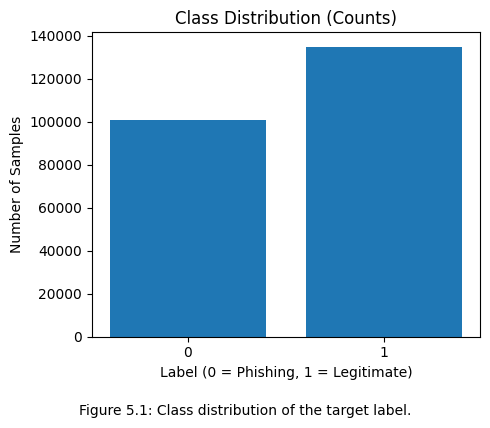

,Label,Count,Percentage (%)
0,0,100945,42.81
1,1,134850,57.19


In [53]:
"""
Class Distribution Plot

Purpose:
- Visualize the distribution of the target label (y) to check class balance.

Inputs:
- y: target Series (0 = phishing, 1 = legitimate).

Outputs:
- Bar chart of class counts.
- Summary table with counts and percentages.
"""

# 1) Count samples per class and compute percentage distribution
counts = y.value_counts().sort_index()
perc   = y.value_counts(normalize=True).sort_index() * 100

# 2) Plot class counts
plt.figure(figsize=(5, 4))
plt.bar(counts.index.astype(str), counts.values)
plt.title("Class Distribution (Counts)")
plt.xlabel("Label (0 = Phishing, 1 = Legitimate)")
plt.ylabel("Number of Samples")
plt.tight_layout()
plt.figtext(
    0.5, -0.05,
    "Figure 5.1: Class distribution of the target label.",
    ha="center", fontsize=10
)
plt.show()

# 3) Tabular summary for exact values
summary = pd.DataFrame({
    "Label":          counts.index,
    "Count":          counts.values,
    "Percentage (%)": perc.round(2).values
})
display(summary)


Figure 5.1 shows a slightly higher number of legitimate samples than phishing. The summary table reports 134,850 legitimate URLs (57.19%) and 100,945 phishing URLs (42.81%) out of 235,795 samples. This is a mild imbalance, so both classes are still well represented for training and evaluation.

Visualizing the class distribution makes it easier to see the balance between classes at a glance. This is important because a highly imbalanced dataset may cause a machine learning model to be biased toward the majority class, predicting the larger class more often.

### 5.2 Feature Preparation

In [54]:
"""
Create EDA feature copy

Purpose:
- Create a working copy of X for EDA so the original is not modified.

Inputs:
- X: original feature DataFrame.

Outputs:
- X_eda: copy used throughout all EDA steps.
"""

# Copy X so EDA operations do not affect the original
X_eda = X.copy()

print("X_eda shape:", X_eda.shape)


X_eda shape: (235795, 54)


We create a copy of the dataset so the original remains unchanged. Then we separate the features from the target column (`label`) to prepare the data for exploratory analysis independently from the prediction target.

In [55]:
"""
Uniqueness check for non-numeric columns

Purpose:
- Examine whether text/identifier columns contain unique or repeated values.
- This informs the decision to drop them before modeling.

Inputs:
- X_eda: feature DataFrame (includes text columns).

Outputs:
- Per-column uniqueness report.
"""

non_numeric_cols = ["FILENAME", "URL", "Domain", "TLD", "Title"]

# Only check columns that exist
existing_text_cols = [c for c in non_numeric_cols if c in X_eda.columns]

print("Uniqueness Check for Non-Numeric Columns")
for col in existing_text_cols:
    total_values  = X_eda[col].shape[0]
    unique_values = X_eda[col].nunique()
    is_unique     = total_values == unique_values
    print(f"\nColumn: {col}")
    print(f"  Total values:  {total_values}")
    print(f"  Unique values: {unique_values}")
    print(f"  All unique?    {is_unique}")
    if not is_unique:
        print(f"  Duplicates:    {total_values - unique_values}")


Uniqueness Check for Non-Numeric Columns

Column: URL
  Total values:  235795
  Unique values: 235370
  All unique?    False
  Duplicates:    425

Column: Domain
  Total values:  235795
  Unique values: 220086
  All unique?    False
  Duplicates:    15709

Column: TLD
  Total values:  235795
  Unique values: 695
  All unique?    False
  Duplicates:    235100

Column: Title
  Total values:  235795
  Unique values: 197874
  All unique?    False
  Duplicates:    37921


We examine the uniqueness of the five non-numeric columns (`FILENAME`, `URL`, `Domain`, `TLD`, and `Title`) to understand whether they can provide meaningful patterns for machine learning.

The output shows that `URL` is nearly unique with only 425 duplicates. `Domain` has 15,709 duplicates, `Title` has 37,921 duplicates, and `TLD` has the most repetition with only 695 unique values out of 235,795.

Although `TLD` and `Domain` show some repetition, the dataset already includes purely numeric features that capture the same structural information in a model-ready form for example, `URLLength` and `DomainLength` capture size, `TLDLength` captures TLD structure, and `NoOfSubDomain` captures domain depth. Raw text columns cannot be fed directly into a numeric model without encoding, and the numeric equivalents already exist, so dropping them loses no meaningful information.

`FILENAME` does not appear in the output because `ucimlrepo` excludes it
from the features matrix (`ds.data.features`)

`FILENAME` and `URL` are identifiers by nature and carry no generalizable signal. `Title` is free form webpage text that would require NLP preprocessing to be useful, which is outside the scope of this phase.

Based on this analysis, all five non-numeric columns will be dropped and only the 50 numeric features are retained for modeling.

In [56]:
"""
Drop text columns and retain numeric features

Purpose:
- Remove raw text identifier columns that cannot be used as ML features.
- Retain only numeric features for statistical analysis and visualization.

Inputs:
- X_eda: feature DataFrame.

Outputs:
- X_eda: numeric-only feature DataFrame (50 features).
"""

# 1) Drop text identifier columns
X_eda = X_eda.drop(columns=["FILENAME", "URL", "Domain", "TLD", "Title"], errors="ignore")

# 2) Keep only numeric features
X_eda = X_eda.select_dtypes(include="number")

print("Numeric feature count:", X_eda.shape[1])
print("X_eda shape:", X_eda.shape)


Numeric feature count: 50
X_eda shape: (235795, 50)


We drop the five non-numeric columns (`FILENAME`, `URL`, `Domain`, `TLD`, `Title`) and keep only the numeric features. The result is a DataFrame with 50 numeric features and 235,795 rows.

### 5.3 Statistical Feature Analysis

In [57]:
"""
Zero-variance feature check

Purpose:
- Identify whether any numerical features have zero variance.
- Features with zero variance have the same value for all samples
  and therefore provide no useful information for predictive models.

Inputs:
- X: pandas DataFrame containing all feature variables.

Outputs:
- Number of numerical features with zero variance.
"""

# Compute the standard deviation of each numeric feature and count
#    how many have a value of zero (indicating no variability)
zero_var_count = (X_eda.std() == 0).sum()

print(f"Number of zero-variance features: {zero_var_count}")

Number of zero-variance features: 0


Before computing summary statistics, we check whether any numeric feature has
zero variance meaning it takes the same value for every sample. Such features
carry no information and would be useless for any model. The output confirms that
no features have zero variance, so all 50 numeric features are retained.

#### 5.3.1 Summary Statistics

In [58]:
"""
Summary statistics for numerical features

Purpose:
- Compute key descriptive statistics for numerical features to understand
  their central tendency and spread.

Inputs:
- X_eda: DataFrame containing only numerical features.

Outputs:
- summary_stats: table showing mean, std, min, and max for each feature.
"""

# 1) Compute descriptive statistics (transpose: each feature as a row)
summary_stats = X_eda.describe().T[["mean", "std", "min", "max"]]

# 2) Display the summary statistics table
summary_stats


,mean,std,min,max
URLLength,34.573095,41.314153,13.000000,6.097000e+03
DomainLength,21.470396,9.150793,4.000000,1.100000e+02
IsDomainIP,0.002706,0.051946,0.000000,1.000000e+00
URLSimilarityIndex,78.430778,28.976055,0.155574,1.000000e+02
CharContinuationRate,0.845508,0.216632,0.000000,1.000000e+00
TLDLegitimateProb,0.260423,0.251628,0.000000,5.229071e-01
URLCharProb,0.055747,0.010587,0.001083,9.082366e-02
TLDLength,2.764456,0.599739,2.000000,1.300000e+01
NoOfSubDomain,1.164758,0.600969,0.000000,1.000000e+01
HasObfuscation,0.002057,0.045306,0.000000,1.000000e+00


The `.describe()` function generates statistical summaries for each numeric feature, including:
- mean: the average value
- std: the standard deviation, which measures how spread out the values are
- min / max: the smallest and largest values

Key observations from the output:
- `URLLength` has a mean of ~34.6 but a maximum of 6,097, indicating extreme outliers (unusually large values far from the majority of the data).
- Many features like `IsDomainIP`, `HasObfuscation`, `IsHTTPS` have a minimum of 0 and maximum of 1 which indicates that they are binary features.
- Features like `URLSimilarityIndex` range from ~0.16 to 100, while `TLDLegitimateProb` ranges from 0 to ~0.52, showing that features exist on very different scales.

The statistical summary indicates considerable variability across several features.
In particular, count-based webpage attributes such as `NoOfExternalRef` and
`LineOfCode` exhibit large ranges and potential skewness, suggesting the presence
of outliers and highly uneven distributions across webpages.

#### 5.3.2 Variance Check

In [59]:
"""
Variance analysis for numerical features

Purpose:
- Measure the variability of each numerical feature.
- Identify features with extremely low variance that provide
  little useful information for predictive modeling.

Inputs:
- X_eda: DataFrame containing only numerical features.

Outputs:
- variance_table: variances sorted descending; top 10 and bottom 10 displayed.
"""

# 1) Compute variance for each numerical feature
variance_table = pd.DataFrame({
    "Variance": X_eda.var()
}).sort_values(by="Variance", ascending=False)

# 2) Display top 10 highest-variance features
print("Top 10 highest-variance features:")
display(variance_table.head(10))

# 3) Display bottom 10 lowest-variance features
print("\nBottom 10 lowest-variance features:")
display(variance_table.tail(10))

# 4) Count features with variance below 0.01
low_var_count = (variance_table["Variance"] < 0.01).sum()
print(f"\nFeatures with variance < 0.01: {low_var_count}")

Top 10 highest-variance features:


,Variance
LargestLineLength,2.316517e+10
LineOfCode,1.169606e+07
NoOfSelfRef,3.121849e+04
NoOfExternalRef,2.592983e+04
NoOfImage,6.306236e+03
NoOfCSS,5.604962e+03
DomainTitleMatchScore,2.467802e+03
URLTitleMatchScore,2.460216e+03
URLLength,1.706859e+03
NoOfLettersInURL,8.462473e+02



Bottom 10 lowest-variance features:


,Variance
NoOfSelfRedirect,0.038498
NoOfQMarkInURL,0.037444
Crypto,0.022923
LetterRatioInURL,0.015207
DegitRatioInURL,0.005026
IsDomainIP,0.002698
HasObfuscation,0.002053
SpacialCharRatioInURL,0.001049
URLCharProb,0.000112
ObfuscationRatio,0.000015



Features with variance < 0.01: 6


The variance analysis shows that no numerical features have zero variance, meaning that all variables vary across the dataset. Some structural features, such as LargestLineLength and LineOfCode, exhibit particularly high variance, reflecting substantial differences in webpage complexity across samples.

At the low end, features with variance below 0.01 are nearly constant across the dataset. A near constant feature provides almost no discriminative power between phishing and legitimate URLs because its value is the same for both classes. Such features add noise, increase training time, and inflate dimensionality without contributing to prediction. Any features identified here will be removed in the preprocessing pipeline.

#### 5.3.3 Skewness Analysis

In [60]:
"""
Skewness analysis for numerical features

Purpose:
- Measure the asymmetry of each numerical feature's distribution.
- Identify features with strong positive or negative skewness,
  which may indicate outliers or long-tailed distributions.

Inputs:
- X_eda: DataFrame containing only numerical features.

Outputs:
- skewness: Series of skewness values sorted descending; top 10 displayed.
"""

# 1) Compute skewness for each numerical feature
skewness = X_eda.skew().sort_values(ascending=False)

# 2) Display the top 10 most positively skewed features
skewness.head(10)


,0
NoOfCSS,464.404031
NoOfObfuscatedChar,204.684335
NoOfJS,140.435761
NoOfEqualsInURL,114.985479
NoOfEmptyRef,106.826225
NoOfAmpersandInURL,106.717256
NoOfiFrame,97.677347
NoOfDegitsInURL,94.877574
NoOfPopup,84.952694
NoOfExternalRef,65.900247


Several count-based webpage features exhibit extreme positive skewness (e.g., NoOfCSS, NoOfJS, NoOfObfuscatedChar), indicating that most webpages contain relatively low counts while a smaller subset displays significantly larger values. This long-tailed distribution reflects substantial variation in webpage structure, where most pages contain relatively few elements while a smaller subset contains much larger counts. Tree-based models are generally robust to such skewness, whereas linear models may require normalization or transformation.

#### 5.3.4 Mean-Median Comparison

In [61]:
"""
Mean–median comparison for skewness confirmation

Purpose:
- Compare mean and median values to confirm skewed distributions.
- Large mean–median gaps indicate skewness or extreme outlier values.

Inputs:
- X_eda: DataFrame containing only numerical features.

Outputs:
- Table of mean, median, and mean_minus_median sorted descending; top 15 shown.
"""

# 1) Compute descriptive statistics
stats = X_eda.describe().T

# 2) Add median column
stats["median"] = X_eda.median()

# 3) Compute mean–median difference (large positives = right skew)
stats["mean_minus_median"] = stats["mean"] - stats["median"]

# 4) Display top 15 most skewed features
stats.sort_values("mean_minus_median", ascending=False).head(15)


,count,mean,std,min,25%,50%,75%,max,median,mean_minus_median
LargestLineLength,235795.0,12789.532624,152201.099228,22.0,200.0,1090.0,8047.0,13975732.0,1090.0,11699.532624
LineOfCode,235795.0,1141.900443,3419.950513,2.0,18.0,429.0,1277.0,442666.0,429.0,712.900443
NoOfSelfRef,235795.0,65.071113,176.687539,0.0,0.0,12.0,88.0,27397.0,12.0,53.071113
NoOfExternalRef,235795.0,49.262516,161.027430,0.0,1.0,10.0,57.0,27516.0,10.0,39.262516
NoOfImage,235795.0,26.075689,79.411815,0.0,0.0,8.0,29.0,8956.0,8.0,18.075689
URLLength,235795.0,34.573095,41.314153,13.0,23.0,27.0,34.0,6097.0,27.0,7.573095
NoOfLettersInURL,235795.0,19.428919,29.090330,0.0,10.0,14.0,20.0,5191.0,14.0,5.428919
NoOfJS,235795.0,10.522305,22.312192,0.0,0.0,6.0,15.0,6957.0,6.0,4.522305
NoOfCSS,235795.0,6.333111,74.866296,0.0,0.0,2.0,8.0,35820.0,2.0,4.333111
NoOfEmptyRef,235795.0,2.377629,17.641097,0.0,0.0,0.0,1.0,4887.0,0.0,2.377629


The mean–median comparison further confirms the presence of strongly right-skewed distributions. For several count-based features (e.g., LargestLineLength, LineOfCode, NoOfExternalRef), the mean is substantially larger than the median. This pattern indicates that while most webpages contain relatively moderate values, a small number of observations exhibit extremely large counts, producing long right tails in the distribution.

### 5.4 Feature Distributions

#### 5.4.1 Distribution Histograms (All Features)

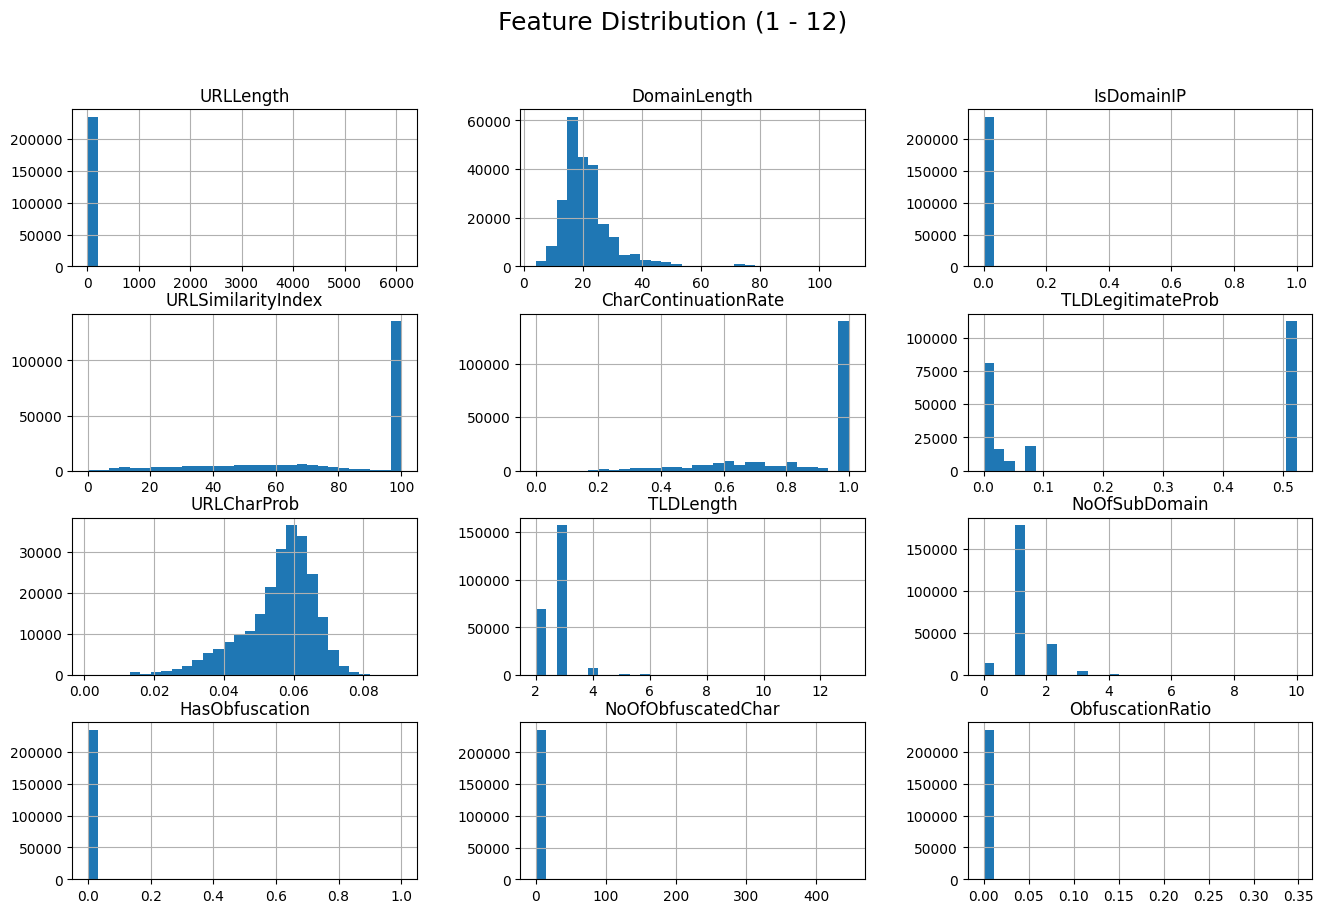

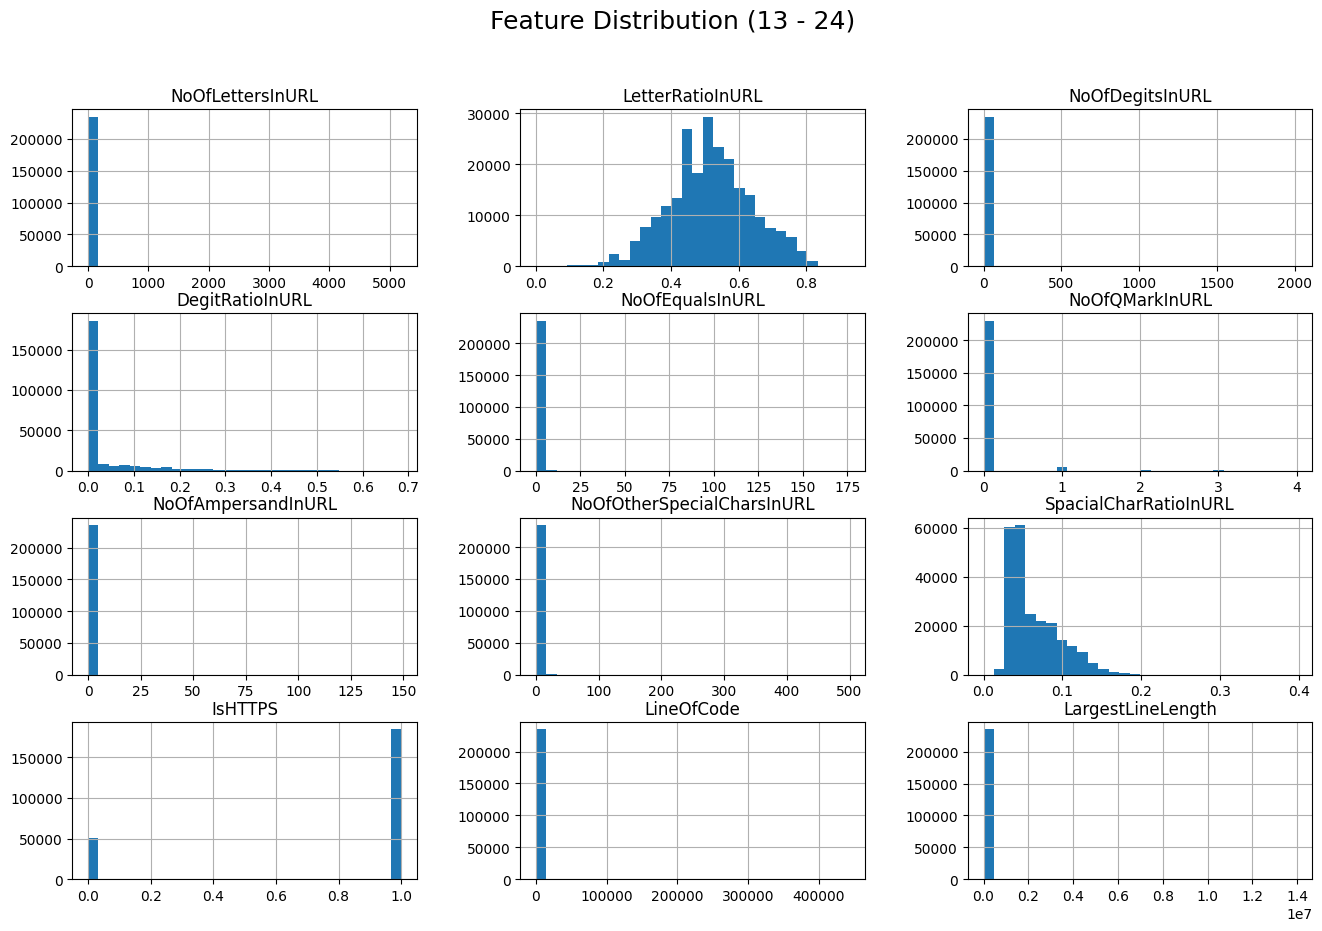

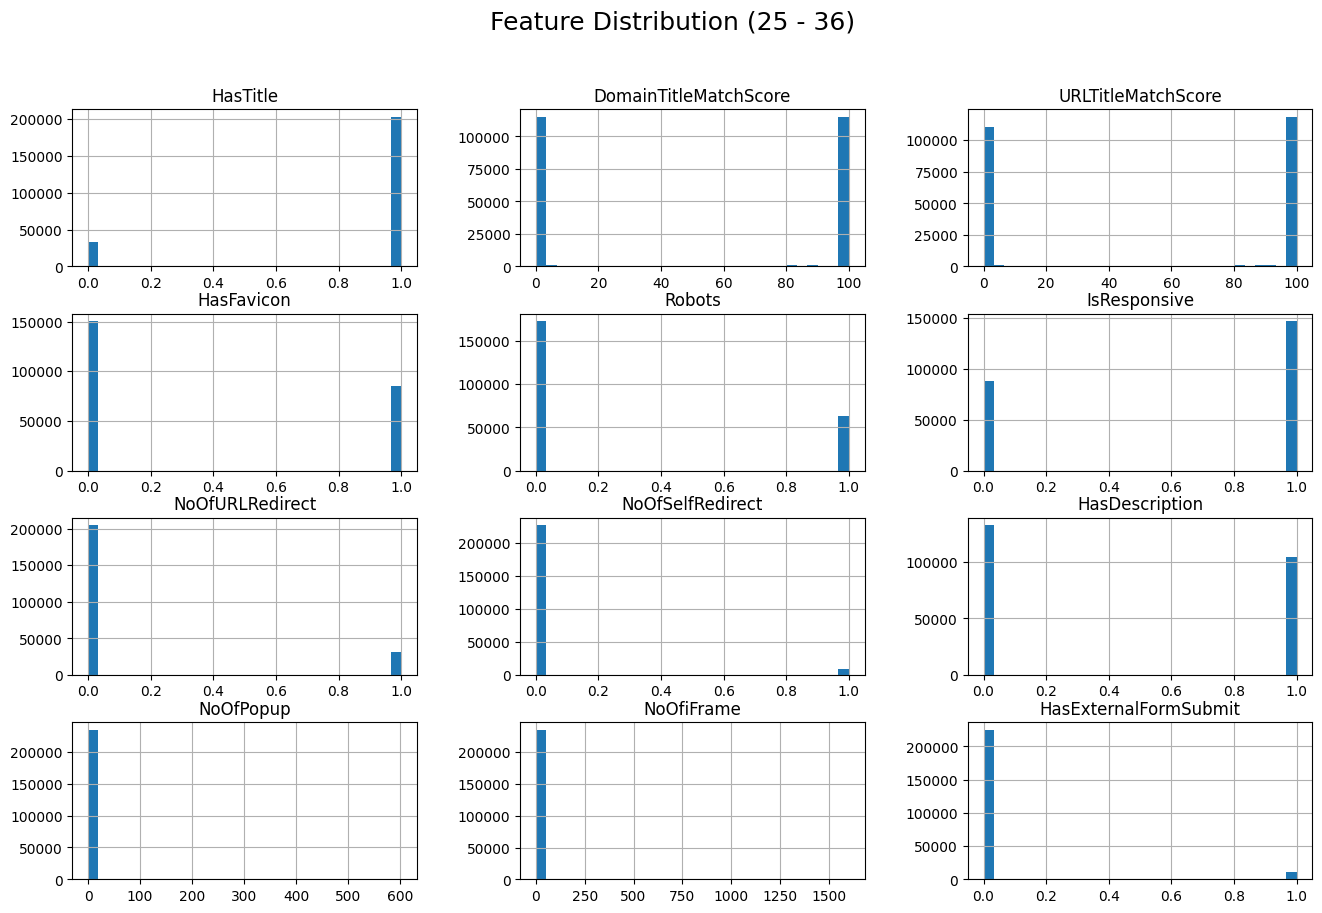

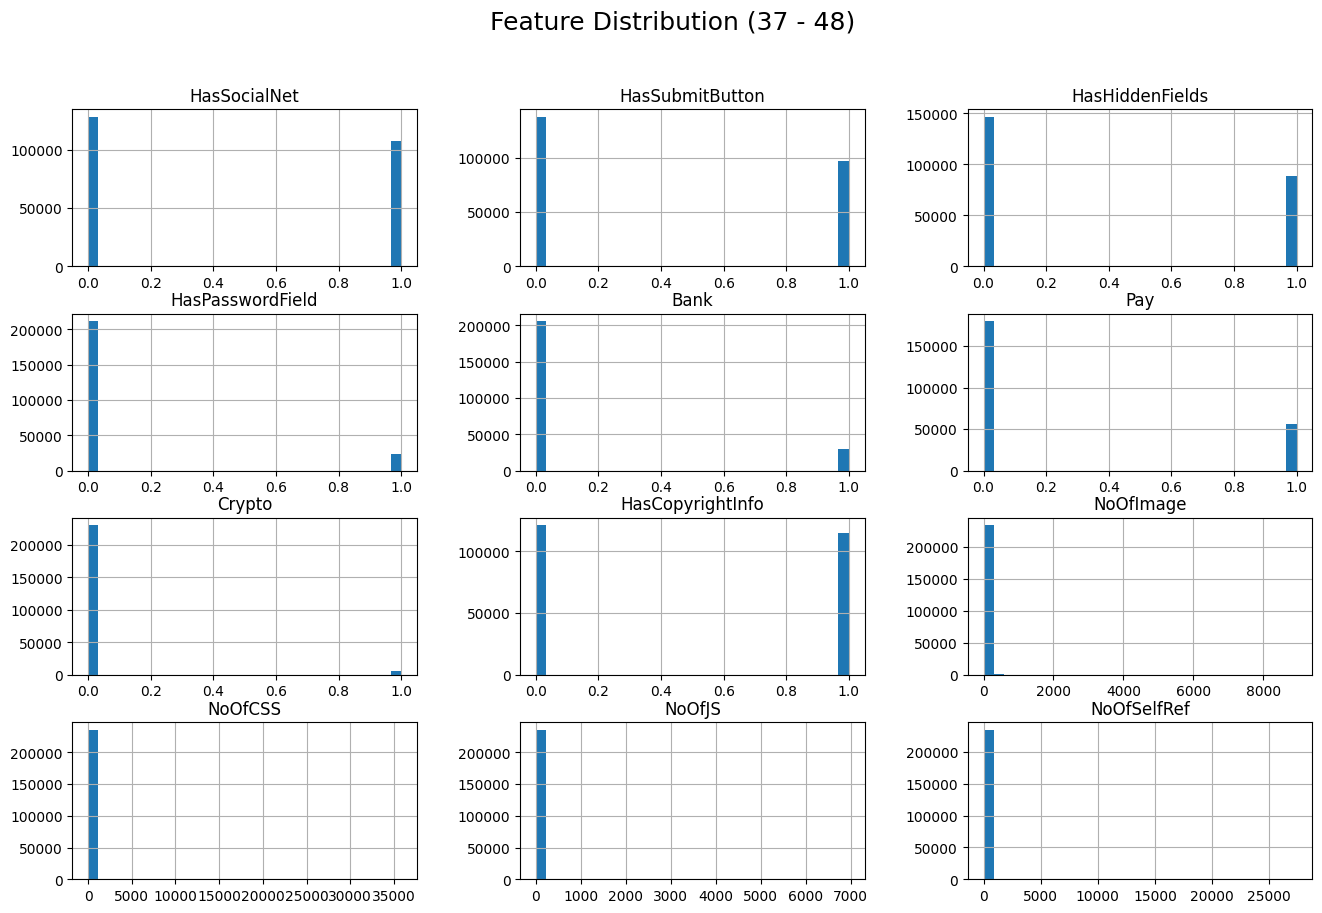

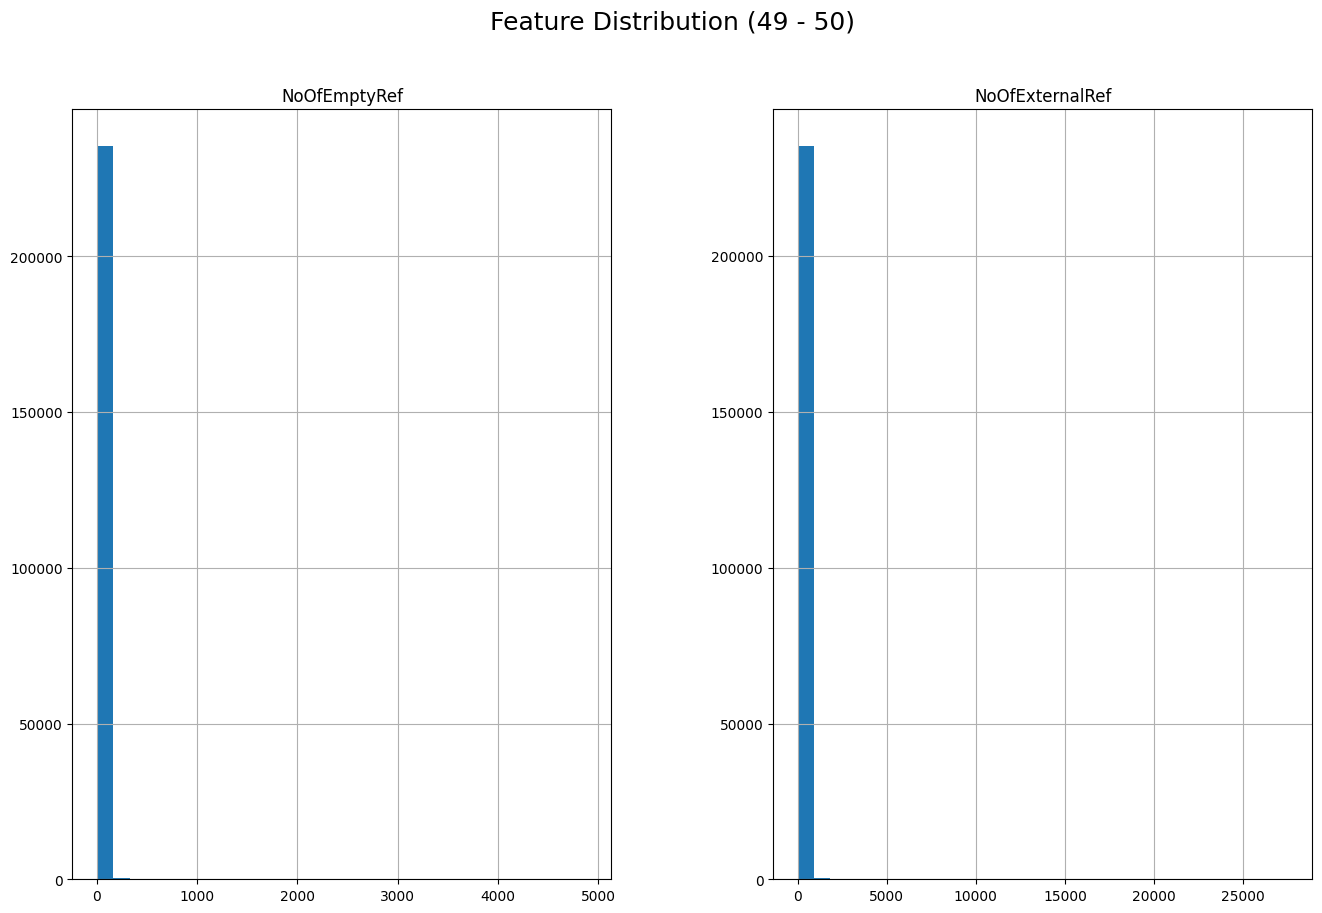

In [62]:
# Get the names of all columns in the dataset
# Each column represents one feature extracted from the URL
features = X_eda.columns

# Define how many features will be displayed in each figure
# This helps avoid overcrowding the plots and improves readability
features_per_plot = 12

# Loop through the features in groups
# Each iteration selects a subset of features to visualize
for i in range(0, len(features), features_per_plot):

    # Select a subset of features from the dataset
    # Example: features 1–12, then 13–24, etc.
    subset = features[i:i+features_per_plot]

    # Plot histograms for the selected subset of features
    # Histograms show how values of each feature are distributed
    X_eda[subset].hist(
        figsize=(16,10), # Increase figure size so plots are clear
        bins=30          # Number of bars in each histogram
    )

    # Add a title to indicate which features are displayed in this figure
    plt.suptitle(f"Feature Distribution ({i+1} - {i+len(subset)})", fontsize=18)

    # Display the plots
    plt.show()

The histograms show how frequently different values appear in a feature. The x-axis shows the range of values, and the y-axis shows how many data points fall into each range (called a bin). The features are plotted in groups of 12 for readability.

Key observations from the histograms:
- Many binary features (e.g., `IsDomainIP`, `HasObfuscation`, `IsHTTPS`) show only two bars at 0 and 1.
- Features like `URLLength` and `LineOfCode` are right-skewed where most values are small, but a few values are very large, creating a long tail to the right.
- Features like `URLSimilarityIndex` and `CharContinuationRate` show more continuous, spread-out distributions (the pattern of how values are spread across the range).

Examining feature distributions helps us understand the shape of the data.
If some features are very skewed, we may apply transformations, which means changing the values using mathematical functions to make the distribution more balanced.
We may also use scaling, which means adjusting the feature values so they are on a similar scale. This prevents features with large values from dominating the model.

#### 5.4.2 Boxplots for Outlier Detection (All Features)

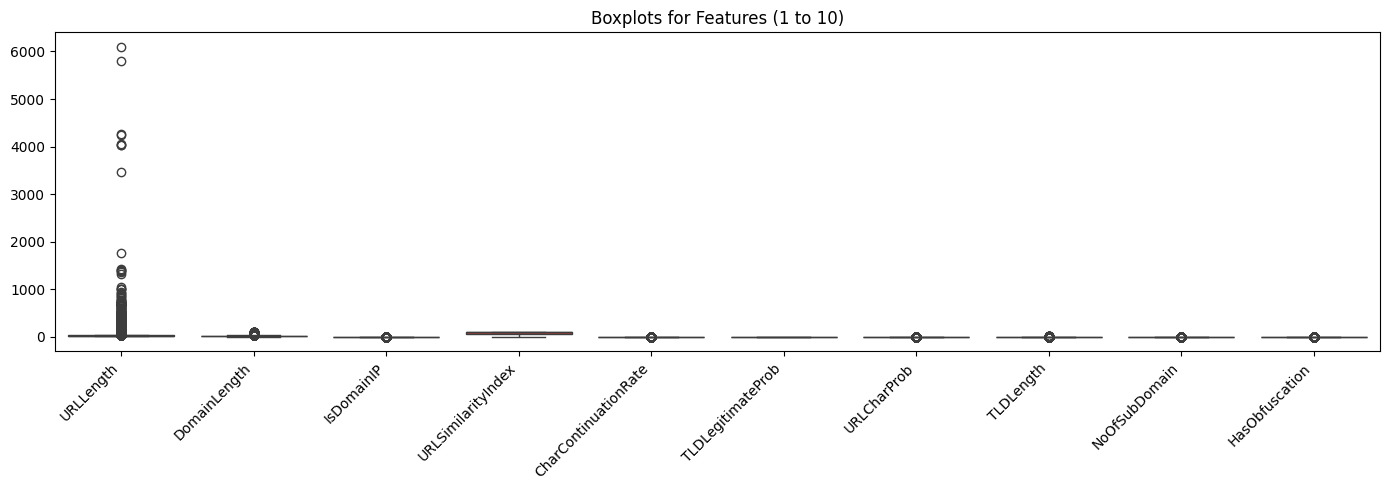

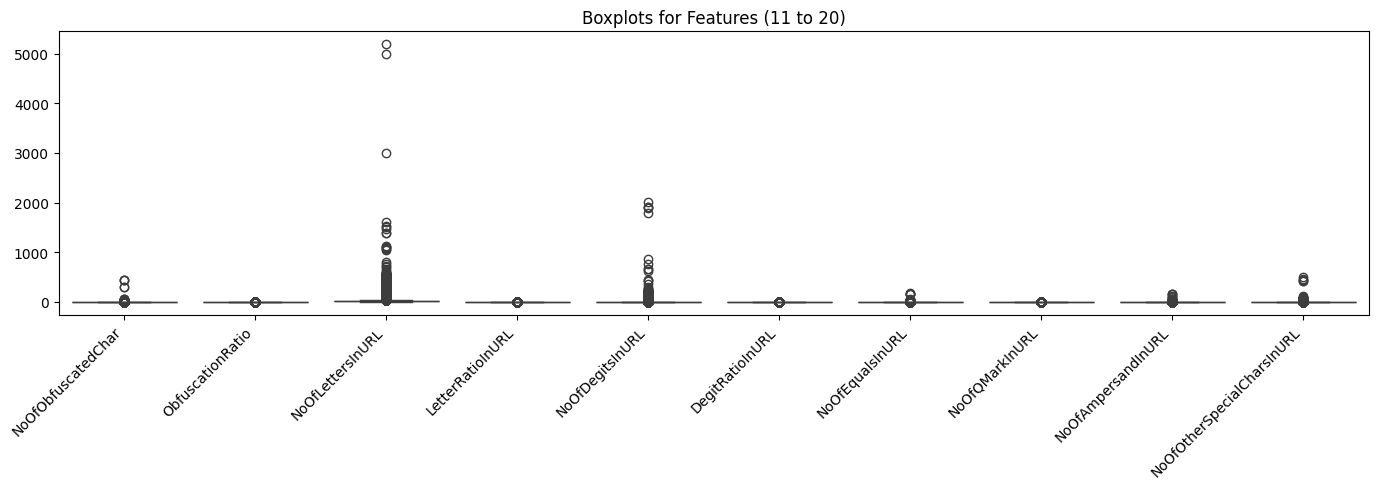

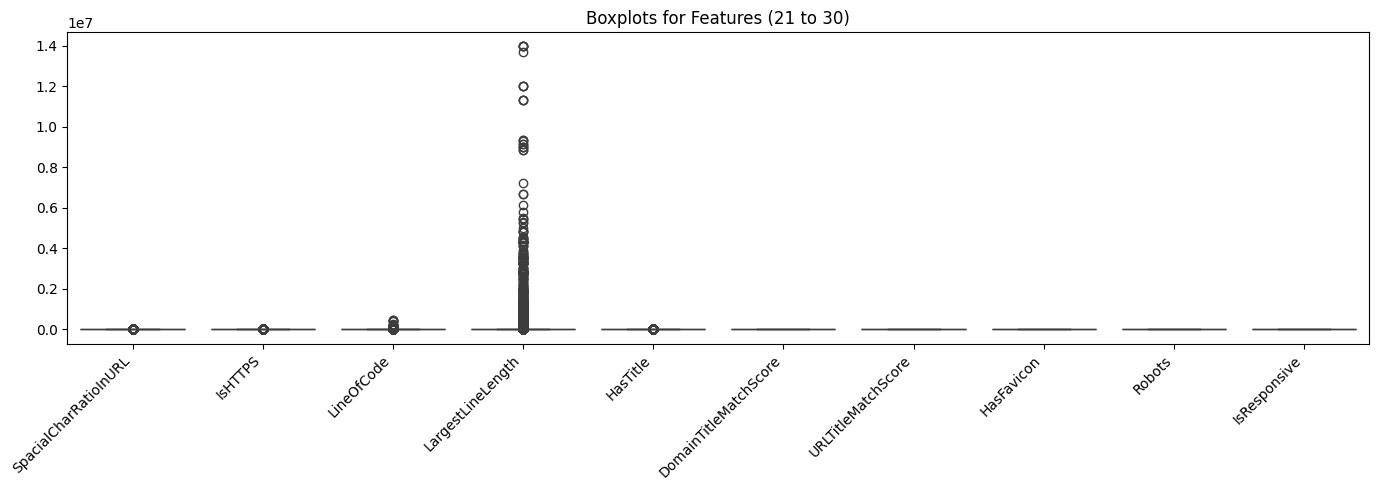

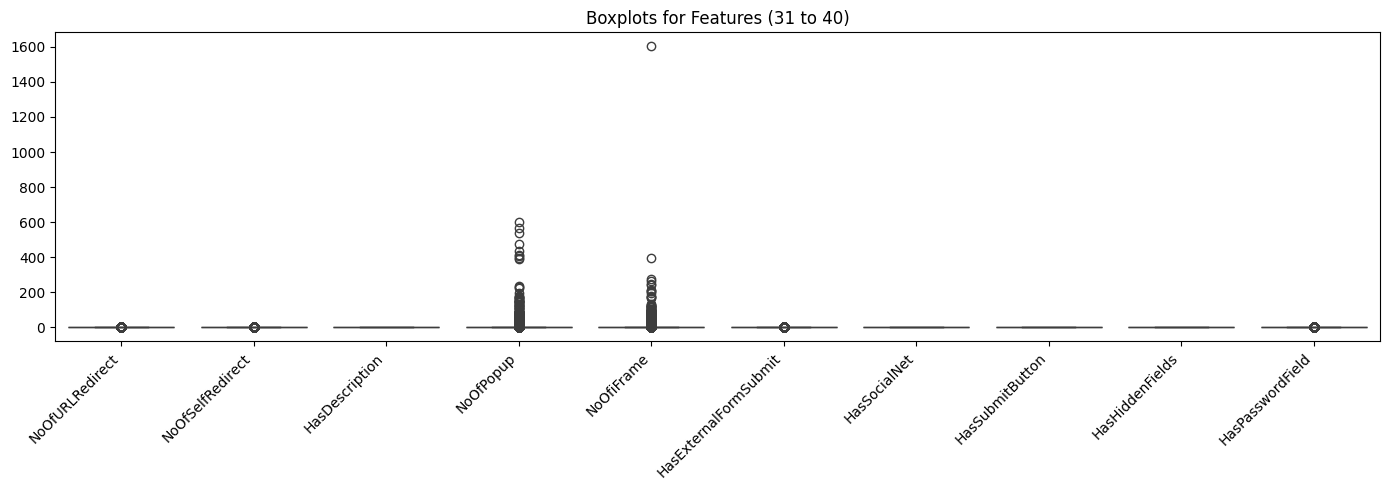

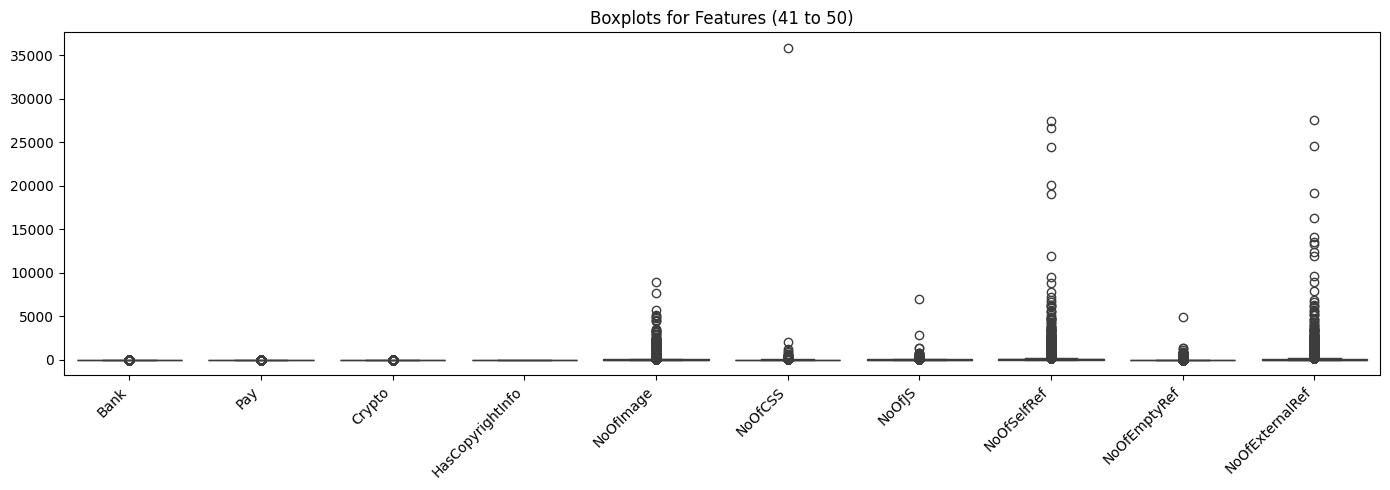

In [19]:
# Split features into groups for readable boxplots
features_list = list(X_eda.columns)

# Set group size
group_size = 10

# Loop through feature groups
for i in range(0, len(features_list), group_size):

    # Select subset of features
    subset = features_list[i:i + group_size]

    # Create figure
    plt.figure(figsize=(14, 5))

    # Plot boxplots for the subset
    sns.boxplot(data=X_eda[subset])

    # Rotate x-axis labels for readability
    plt.xticks(rotation=45, ha="right")

    # Add title
    plt.title(f"Boxplots for Features ({i+1} to {i+len(subset)})")
    plt.tight_layout()
    plt.show()

The boxplots show the spread of data for each feature. The box represents the data, the line inside the box is the median, and the dots or points represent outliers (values that are unusually far from the rest of the data). The features are plotted in groups of 10 for readability.

Key observations from the boxplots:
- Features such as `NoOfLettersInURL`, `LineOfCode`, `LargestLineLength`, `NoOfImage`, `NoOfJS`, and `NoOfExternalRef` have significant outliers visible as dots far above most of the data points.
- Binary features (values 0 or 1 only) show no outliers because they only take two possible values.

Outliers in this dataset may represent unusual URLs (for example, very long phishing URLs or pages with many hidden elements). These extreme values could carry important information for phishing detection, so we will not remove them at this stage.

#### 5.4.3 Focused View: Top 5 Most Skewed Features

The following histograms and boxplots focus on the five most positively skewed features identified above.

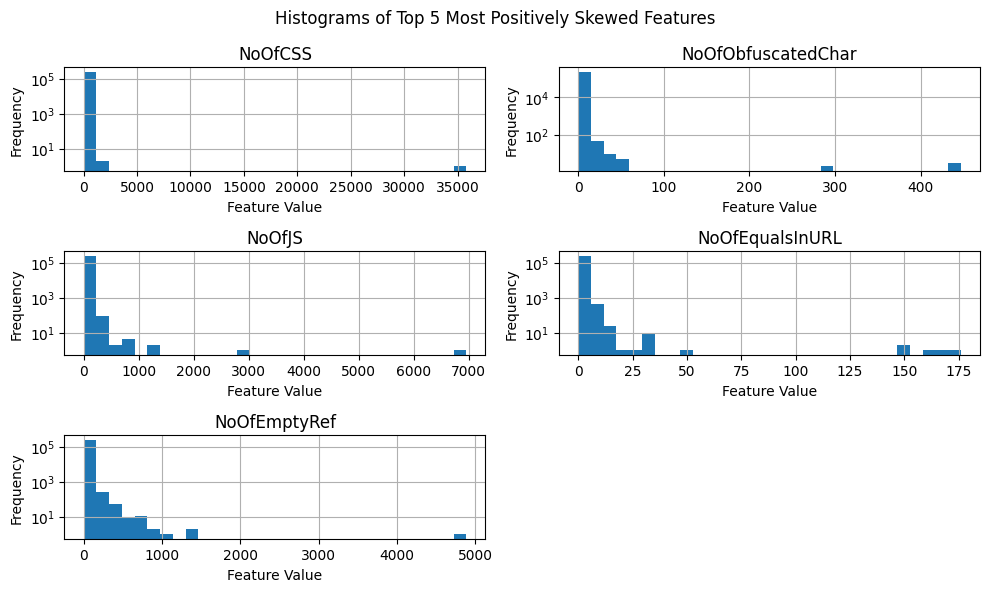

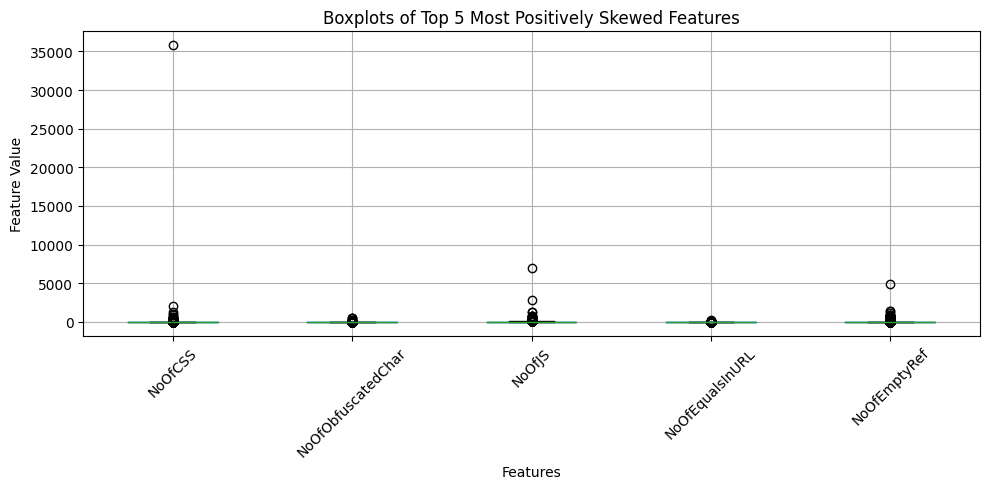

In [20]:
"""
Histogram Visualization of Top 5 Most Skewed Features

Purpose:
- Visualize the distribution of the most positively skewed numerical features.
- Histograms help reveal the distribution shape and confirm the presence of long-tailed behavior.

Axes Interpretation:
- X-axis: Feature value (e.g., number of CSS files, scripts, or structural elements in a webpage).
- Y-axis: Frequency (number of webpages that contain that value).

Inputs:
- X: DataFrame containing feature variables.
- top_skewed_features: list of the five most positively skewed features.

Outputs:
- Histograms showing the distribution of these highly skewed variables.
"""

# Select the five most positively skewed features
top_skewed_features = skewness.head(5).index

axes = X_eda[top_skewed_features].hist(figsize=(10,6), bins=30, log=True)

for ax in axes.flatten():
    ax.set_xlabel("Feature Value")
    ax.set_ylabel("Frequency")

plt.suptitle("Histograms of Top 5 Most Positively Skewed Features")
plt.tight_layout()
plt.show()


"""
Boxplot Visualization of Top 5 Most Skewed Features

Purpose:
- Visualize the spread and detect extreme outliers in the most positively skewed features.
- Boxplots summarize the distribution using quartiles and highlight outliers.

Axes Interpretation:
- X-axis: Selected feature names.
- Y-axis: Feature values.

Outputs:
- Boxplots showing variability and extreme values in the selected skewed features.
"""


plt.figure(figsize=(10,5))
X_eda[top_skewed_features].boxplot()
plt.xticks(rotation=45)
plt.xlabel("Features")
plt.ylabel("Feature Value")
plt.title("Boxplots of Top 5 Most Positively Skewed Features")
plt.tight_layout()
plt.show()

To further investigate the skewness identified in the statistical analysis, we visualized the five most positively skewed features using histograms and boxplots. These plots help reveal the distribution shape and highlight extreme values. (Note: A logarithmic scale is used in the histograms to better visualize highly skewed frequency distributions).

The histograms show that most observations are concentrated near very small values, while a small number of samples exhibit extremely large values, producing long right-tailed distributions.

 The boxplots further confirm this pattern by revealing numerous high-value outliers beyond the upper whiskers. Such long-tailed behavior is common in count-based webpage features, where most pages contain relatively few structural elements while a smaller subset contains unusually large counts.

  These extreme structural variations may provide useful signals for distinguishing phishing webpages from legitimate ones.

### 5.5 Feature Group Interpretation

Beyond individual feature statistics, it is useful to understand what each feature group actually measures and critically whether that information is available at the moment a user clicks a URL, before the page loads.

We Apply a "First Contact" test, we categorize features by when they become observable:

1- lexical/URL-string features derived directly from the URL text (length, digit/special-character ratios, obfuscation, HTTPS) are available immediately and retained.

2- DNS/WHOIS signals (e.g., IP-based domain, TLD structure) require only a lightweight lookup and are retained.

3- page content signals (HTML structure, JavaScript/iframe counts, forms, images) require fetching and parsing the page and therefore are incompatible with pre-click classification.

 The following subsections document the taxonomy and then address redundancy among retained features.

#### 5.5.1 Identifying Redundant Count-Ratio Pairs

In [21]:
"""
Identify count-ratio feature pairs

Purpose:
- List the count-ratio pairs present in the dataset based on naming conventions.
- Each ratio is derived from its corresponding count, so keeping both
  duplicates the same underlying signal.

Inputs:
- X_eda: numeric feature DataFrame.

Outputs:
- Table of count-ratio pairs identified by name.
"""

# 1) Define the known count-ratio pairs based on feature naming conventions
count_ratio_pairs = [
    ("NoOfObfuscatedChar",         "ObfuscationRatio"),
    ("NoOfDegitsInURL",            "DegitRatioInURL"),
    ("NoOfOtherSpecialCharsInURL", "SpacialCharRatioInURL")
]

# 2) Display as a table
pair_table = pd.DataFrame(count_ratio_pairs, columns=["Count Feature", "Ratio Feature"])
display(pair_table)

,Count Feature,Ratio Feature
0,NoOfObfuscatedChar,ObfuscationRatio
1,NoOfDegitsInURL,DegitRatioInURL
2,NoOfOtherSpecialCharsInURL,SpacialCharRatioInURL


The feature names themselves reveal three count-ratio pairs: each ratio is derived from its corresponding count. Since the ratio is computed from the count and a normalizing denominator already present in the dataset, keeping both duplicates the same underlying signal. Retaining only the raw count is sufficient; tree-based models can learn any such derived relationship directly.

`LetterRatioInURL` is an orphaned ratio feature because its count counterpart `NoOfLettersInURL` was already identified for removal due to high correlation with `URLLength`. Without its count pair, the ratio alone is less informative and arguably redundant.

These four ratio features (`ObfuscationRatio`, `DegitRatioInURL`, `SpacialCharRatioInURL`, `LetterRatioInURL`) will be removed in the preprocessing pipeline to reduce redundancy.

#### 5.5.2 Feature Group Taxonomy


Group 1: Identifiers

Features such as FILENAME, URL, Domain, TLD, and Title are raw strings with no numeric meaning. Since length-based and structural equivalents are already present in the dataset, these identifiers are dropped before any further processing.

Group 2: Label-Leaking Features

Six features share a critical flaw: they were computed by comparing URLs against a labeled reference corpus, so they effectively encode the ground-truth label. A model trained on them reaches near-perfect validation accuracy yet collapses on any URL it has never seen. The affected features are URLSimilarityIndex, URLCharProb, TLDLegitimateProb, CharContinuationRate, DomainTitleMatchScore, and URLTitleMatchScore, all of which are dropped unconditionally.

Group 3: Page-Content Features

A phishing detector that must respond before the user clicks cannot afford to fetch and parse the target page. The features below all require fetching the page first, as they are computed from live HTML, active elements, or loaded assets, making them unavailable the moment a URL is first seen. HTML structure features (LineOfCode, LargestLineLength, HasTitle, DomainTitleMatchScore, URLTitleMatchScore, HasFavicon, Robots, IsResponsive), active element features (NoOfPopup, NoOfiFrame, HasExternalFormSubmit, HasSocialNet, HasSubmitButton, HasHiddenFields, HasPasswordField), asset references (NoOfImage, NoOfCSS, NoOfJS, NoOfSelfRef, NoOfEmptyRef, NoOfExternalRef), and page content signals (Bank, Pay, Crypto, HasCopyrightInfo, HasDescription) are all excluded from the fast model.

Group 4: Lexical / URL-String Features

These features are computed purely from the URL string and are available the instant a URL is typed or clicked, making them the practical backbone of the fast model. They span URL structure (URLLength, DomainLength, IsDomainIP, TLDLength, NoOfSubDomain), obfuscation indicators (HasObfuscation, NoOfObfuscatedChar, ObfuscationRatio), character composition (NoOfLettersInURL, LetterRatioInURL, NoOfDegitsInURL, DegitRatioInURL), special character counts (NoOfEqualsInURL, NoOfQMarkInURL, NoOfAmpersandInURL, NoOfOtherSpecialCharsInURL, SpacialCharRatioInURL), and the security indicator IsHTTPS.

Group 5: Count-Ratio Redundant Pairs

Each ratio in this group is simply its paired count divided by URL length. Retaining both would duplicate the same signal at two scales, inflating the feature space without adding information, as the correlation evidence in Section 5.5.2 confirms. The ratio is therefore dropped in each pair, leaving only the raw count.

### 5.6 Correlation Analysis

#### 5.6.1 Correlation Heatmap (Feature-Feature)

In this subsection, we visualize the correlation between numeric features to see how strongly pairs of features vary together. We use a Pearson correlation heatmap because it gives a simple and widely used measure of linear relationships between numeric variables. The main goal here is to spot highly correlated feature groups, which may indicate overlapping information that could be considered later during feature selection.

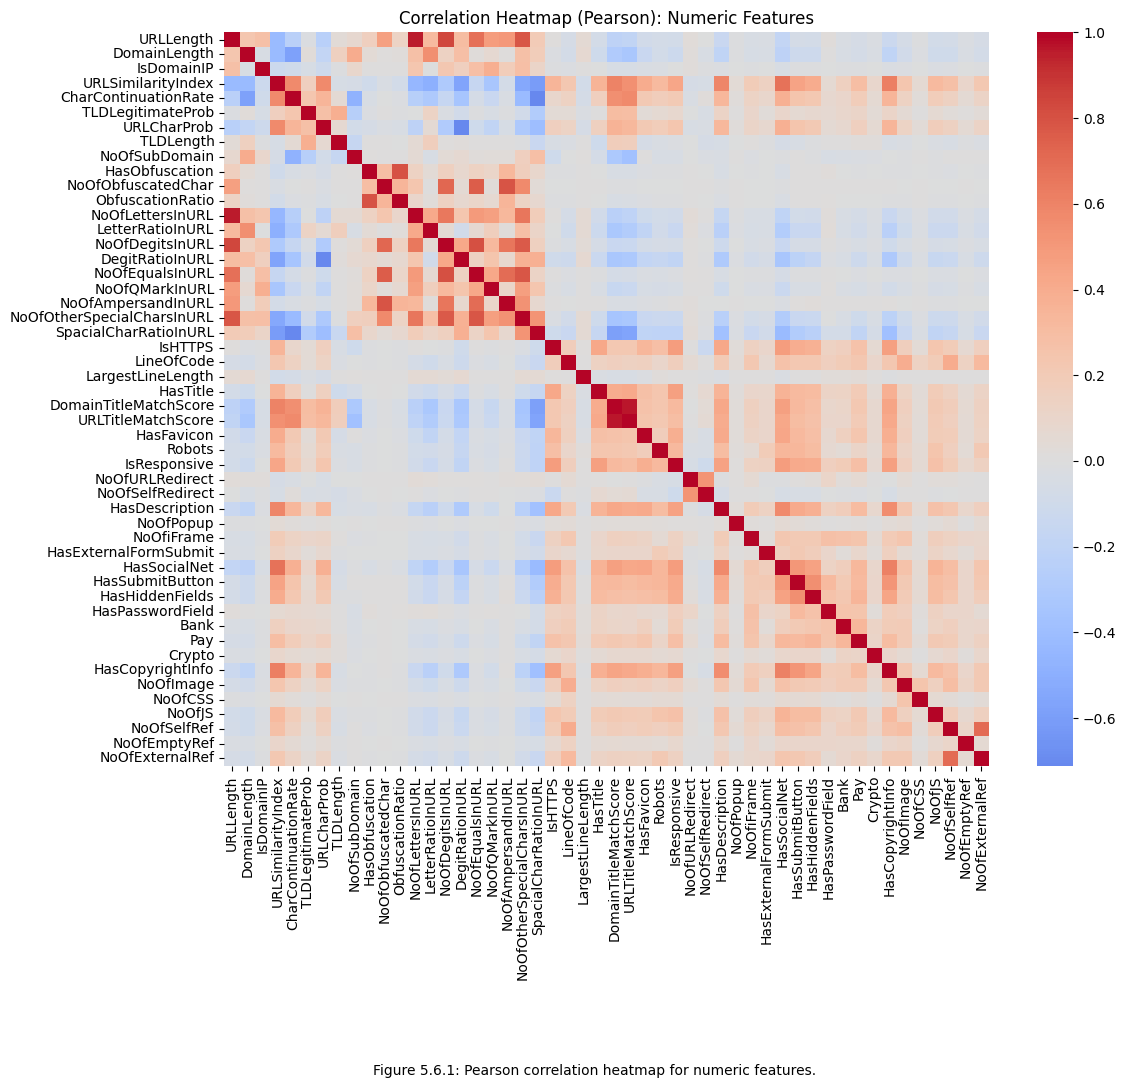

In [22]:
"""
Correlation Heatmap

Purpose:
- Compute and visualize the pairwise Pearson correlation between numeric features.
- Identify strongly correlated feature groups (potential redundancy) before modeling.

Inputs:
- X_eda: numeric feature DataFrame.

Outputs:
- Pearson correlation heatmap.
"""

# 1) Compute Pearson correlation matrix
corr_matrix = X_eda.corr(method="pearson")

# 2) Visualize as a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (Pearson): Numeric Features")
plt.tight_layout()
plt.figtext(
    0.5, -0.08,
    "Figure 5.6.1: Pearson correlation heatmap for numeric features.",
    ha="center", fontsize=10
)
plt.show()


The heatmap visualizes the pairwise Pearson correlation between all 50 numeric
features. Correlation ranges from -1 to +1: values near +1 mean the two
features increase together, values near -1 mean one increases as the other
decreases, and values near 0 indicate no linear relationship. In the heatmap,
warm colors (red) represent positive correlation and cool colors (blue)
represent negative correlation.

Most feature pairs show weak correlations, meaning they capture different
patterns. However, a few high-correlation clusters are visible. For example,
URL-based count features such as `URLLength`, `NoOfLettersInURL`, and
`NoOfDegitsInURL` correlate with each other since they describe related
aspects of the same URL structure. Identifying such redundancies is important
because highly correlated features carry overlapping information, which can
inflate dimensionality and reduce model interpretability. These pairs will be
addressed during preprocessing.

#### 5.6.2 Feature-Target Correlation

 We ranked all numerical features using absolute Pearson correlation with the target variable. This provides a measure of the strength of the linear relationship between each feature and the label independently. Correlation-based ranking helps identify features that are strongly associated with phishing or legitimate classes, but it does not capture feature interactions or non-linear effects.

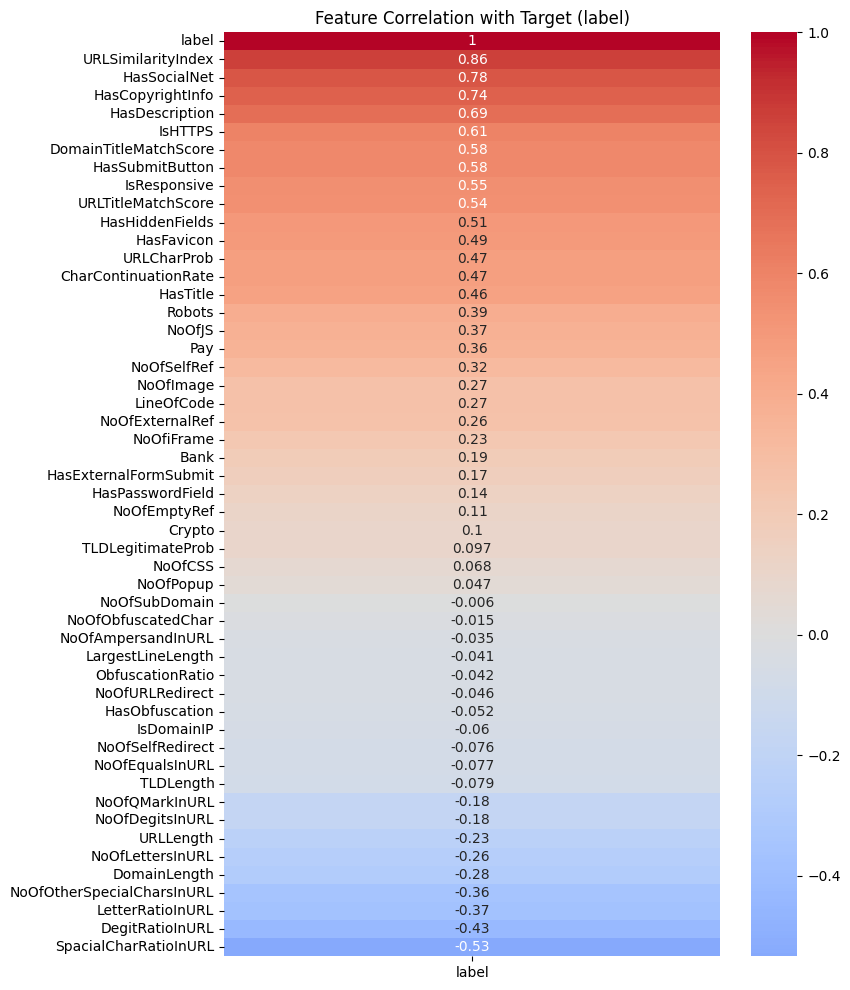

In [23]:
"""
Feature–Target Correlation Heatmap

Purpose:
- Visualize correlation of every feature with the target label as an annotated heatmap.

Inputs:
- X_eda: numeric feature DataFrame.
- y: target Series.

Outputs:
- Annotated heatmap of feature–target correlations.
"""

# 1) Combine features with target
eda_with_label = X_eda.copy()
eda_with_label[target_column] = y.values

# 2) Compute correlation of each feature with target, sorted descending
corr_with_label = eda_with_label.corr()[target_column].sort_values(ascending=False)

# 3) Plot annotated heatmap
plt.figure(figsize=(8, 12))
sns.heatmap(
    corr_with_label.to_frame(),
    annot=True,
    cmap="coolwarm",
    center=0
)
plt.title("Feature Correlation with Target (label)")
plt.show()


This heatmap shows the Pearson correlation between each feature and the
target label. Features with a high positive correlation are more associated
with legitimate websites (label = 1), while high negative correlation means
more associated with phishing (label = 0).

The top correlated features are:

- `URLSimilarityIndex` (0.86): by far the highest correlation of any feature.
  However, this is a warning sign rather than a useful signal.
- `HasSocialNet` (0.78): legitimate sites more often include links to social
  media platforms.
- `HasCopyrightInfo` (0.74): legitimate sites typically display copyright
  information.
- `HasDescription` (0.69): legitimate sites usually include a meta description
  tag.
- `IsHTTPS` (0.61): legitimate sites tend to use the secure HTTPS protocol.
  This is a genuine, computationally free lexical signal readable directly
  from the URL scheme before the page loads. It is retained. However, its
  correlation in this dataset reflects a sampling artifact: legitimate URLs
  were sourced from top-ranked domains that are uniformly HTTPS, which
  overstates the feature's real-world separating power. This is discussed
  further in Section 5.6.2.1.

  Understanding which features correlate most strongly with the target variable helps us identify which features are likely to be most useful for the model. Features with very low correlation may contribute little to prediction accuracy. This analysis provides preliminary feature importance insights before model training.

In [63]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


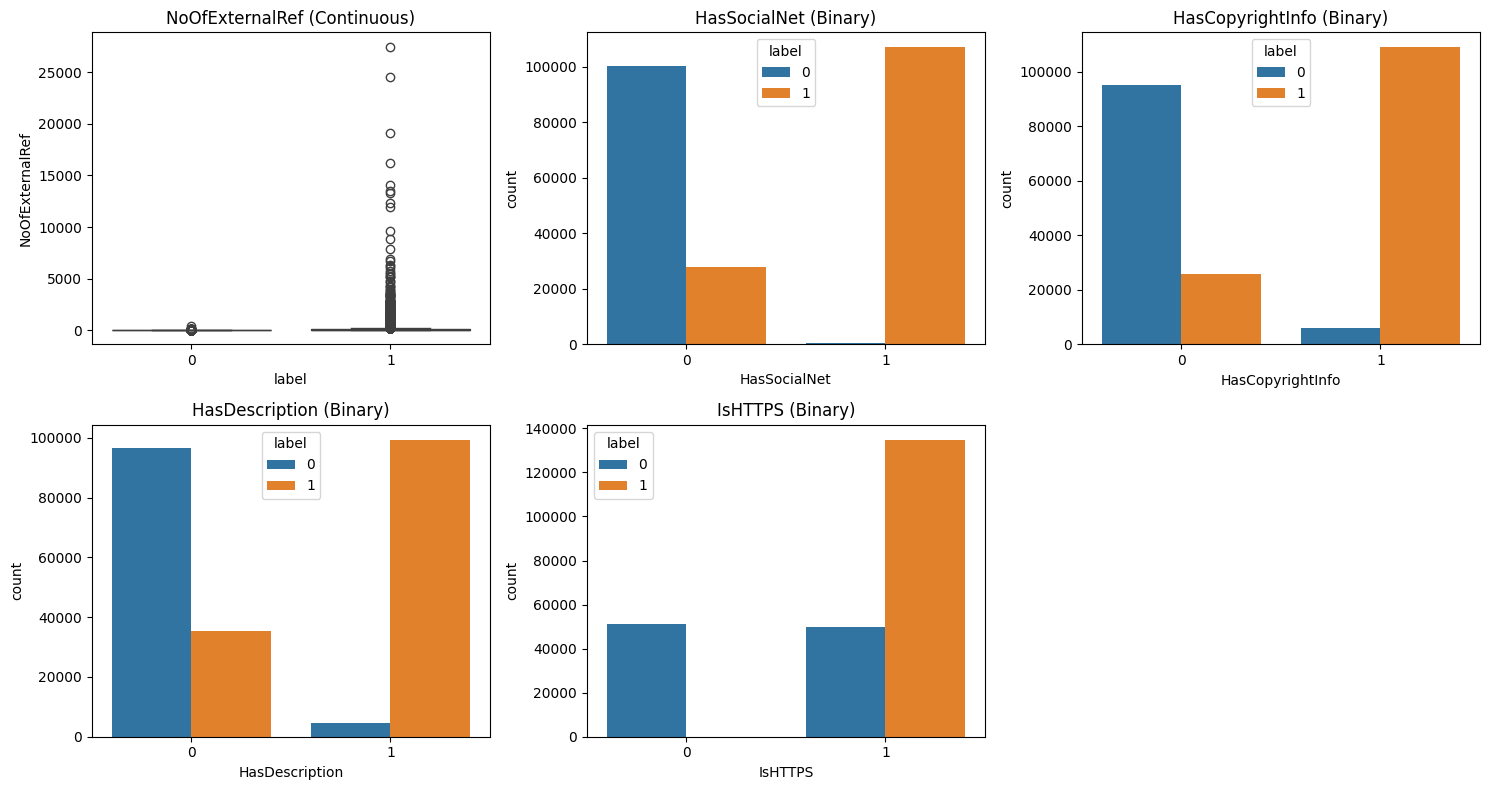

In [24]:
"""
Top Genuine Feature Distributions by Class

Purpose:
- Visualize how the top genuine features differ between phishing and legitimate sites.
- Binary features use count plots; continuous features use box plots.

Inputs:
- X_eda: numeric feature DataFrame.
- y: target Series.

Outputs:
- Grid of 5 plots, one per top feature.
"""

top_features = [
    "NoOfExternalRef",
    "HasSocialNet",
    "HasCopyrightInfo",
    "HasDescription",
    "IsHTTPS"
]

# 1) Build combined DataFrame for plotting
plot_df = X_eda[top_features].copy()
plot_df[target_column] = y.values

# 2) Plot each feature against the target
plt.figure(figsize=(15, 8))
for i, feature in enumerate(top_features, 1):
    plt.subplot(2, 3, i)
    if plot_df[feature].nunique() == 2:
        sns.countplot(x=feature, hue=target_column, data=plot_df)
        plt.title(f"{feature} (Binary)")
    else:
        sns.boxplot(x=target_column, y=feature, data=plot_df)
        plt.title(f"{feature} (Continuous)")
plt.tight_layout()
plt.show()


The plots show how the top correlated features differ between phishing and
legitimate sites.

`NoOfExternalRef` shows a clear distributional difference between classes:
legitimate sites tend to have a higher number of external references.

The three page-content binary features (`HasSocialNet`, `HasCopyrightInfo`,
`HasDescription`) show clear class differences reflecting real behavioral
patterns: legitimate sites invest in trust signals that phishing pages
typically omit.

`IsHTTPS` shows the starkest separation of all: every legitimate URL in the
dataset uses HTTPS, while only around 49% of phishing URLs do. The feature is
a genuine and computationally free phishing signal and is retained.

##### 5.6.2.1 IsHTTPS: Genuine Signal with Dataset Sampling Caveat

In [25]:
"""
IsHTTPS distribution by class

Purpose:
- Compute the percentage of IsHTTPS values within each class

Inputs:
- X_eda: numeric feature DataFrame.
- y: target Series.

Outputs:
- Cross-tabulated percentages of IsHTTPS by class.
"""

# 1) Build a temporary DataFrame with IsHTTPS and the target
https_df = pd.DataFrame({
    "IsHTTPS": X_eda["IsHTTPS"],
    "label":   y.values
})

# 2) Cross-tabulate and normalize by row (per class)
https_dist = pd.crosstab(
    https_df["label"],
    https_df["IsHTTPS"],
    normalize="index"
) * 100

https_dist.columns = ["IsHTTPS = 0 (%)", "IsHTTPS = 1 (%)"]
https_dist.index   = ["Phishing (0)", "Legitimate (1)"]

display(https_dist.round(2))

,IsHTTPS = 0 (%),IsHTTPS = 1 (%)
Phishing (0),50.78,49.22
Legitimate (1),0.00,100.00


`IsHTTPS` records whether the URL uses the HTTPS scheme. It is a genuine
phishing signal: HTTPS requires obtaining a certificate, which adds friction
that opportunistic phishing campaigns often skip. It is also a lexical feature
readable from the URL string with no network call. For both reasons it is
retained throughout preprocessing.

However, the distribution in this dataset deserves scrutiny:

| Class | IsHTTPS = 0 | IsHTTPS = 1 |
|---|---|---|
| Phishing | 50.78% | 49.22% |
| Legitimate | 0.00% | 100.00% |

Every legitimate URL in PhiUSIIL uses HTTPS. This is a direct consequence of
how the dataset was constructed: legitimate URLs were sourced from the Domcop
top 10 million domain ranking, which consists almost entirely of established
sites that adopted HTTPS long ago. The full legitimate URL space includes
small sites, internal tools, and legacy pages that may still use HTTP.

This is not leakage, because the feature was computed purely from the URL
string with no label information involved. The perfect separation is a
sampling artifact. However, it means a model trained on this data will
effectively learn the rule "if not HTTPS, then phishing" with very high
confidence, producing false positives on legitimate HTTP URLs in deployment.

We retain `IsHTTPS` because dropping a valid, zero cost signal over a dataset
limitation would be the wrong correction. Instead, we acknowledge this as a
known limitation and interpret model confidence on this feature with caution.

#### 5.6.3 Multicollinearity Check

In [26]:
"""
Redundancy / multicollinearity check

Purpose:
- Identify pairs of numerical features that are highly correlated.
- Highly correlated features may contain redundant information and
  can increase multicollinearity in some models.

Inputs:
- X_eda: DataFrame containing only numerical features.

Outputs:
- Table showing feature pairs with pairwise correlation above threshold.
"""

# 1) Compute absolute Pearson correlation matrix
high_corr = X_eda.corr().abs()

# 2) Identify pairs with correlation > 0.85 (excluding self-correlations)
high_corr_pairs = high_corr[(high_corr > 0.85) & (high_corr < 1)]

# 3) Drop rows/columns that are all NaN
high_corr_pairs.dropna(how="all").dropna(axis=1, how="all")


,URLLength,NoOfLettersInURL,DomainTitleMatchScore,URLTitleMatchScore
URLLength,NaN,0.956047,NaN,NaN
NoOfLettersInURL,0.956047,NaN,NaN,NaN
DomainTitleMatchScore,NaN,NaN,NaN,0.961008
URLTitleMatchScore,NaN,NaN,0.961008,NaN


The multicollinearity check identified two feature pairs with correlation
above 0.85:

- `URLLength` and `NoOfLettersInURL` (0.96)
- `DomainTitleMatchScore` and `URLTitleMatchScore` (0.96)

These high correlations indicate that each pair carries nearly identical
information. `URLLength` counts every character in the URL, while
`NoOfLettersInURL` counts only alphabetic characters, so the two naturally
move together. `DomainTitleMatchScore` and `URLTitleMatchScore` both measure
how closely the URL or domain matches the webpage title, capturing the same
similarity signal at slightly different scopes. Retaining both features in
each pair would duplicate the same signal without adding predictive value.

### 5.7 Preliminary Feature Importance

In this subsection, we perform a preliminary feature-importance analysis to obtain an early indication of which variables are most informative for distinguishing phishing (0) from legitimate (1) URLs. We use a Random Forest classifier as a baseline because it can capture non-linear relationships and interactions between features without strong distribution assumptions. Since this dataset already includes many engineered numeric indicators (e.g., counts, ratios, and structural flags extracted from URL and webpage characteristics), we compute importance scores using the numeric feature set as a practical first step before any text-specific processing.

,Rank,Feature,Importance
0,1,URLSimilarityIndex,0.197422
1,2,NoOfExternalRef,0.165641
2,3,LineOfCode,0.131394
3,4,NoOfImage,0.112452
4,5,NoOfSelfRef,0.086916
5,6,NoOfJS,0.075427
6,7,HasSocialNet,0.032871
7,8,NoOfCSS,0.030886
8,9,NoOfOtherSpecialCharsInURL,0.023214
9,10,HasDescription,0.023070


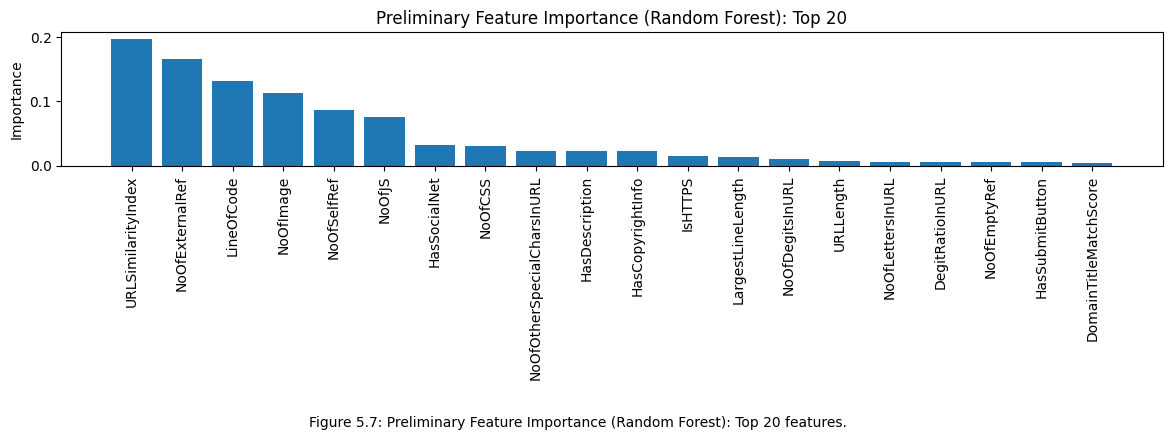

In [27]:

"""
Preliminary Feature Importance (Random Forest)

Purpose:
- Train a baseline Random Forest classifier and rank features by importance.
- Show results in a ranked table and bar chart.

Inputs:
- X_eda: numeric feature DataFrame.
- y: target Series.

Note:
- Uses a temporary 80/20 split for this EDA step only.
- X_rf_train / X_rf_test do NOT affect the preprocessing splits in Section 6.

Outputs:
- Top-20 ranked importance table and bar chart.
"""

# 1) Temporary stratified split (EDA only separate from Section 6 splits)
X_rf_train, X_rf_test, y_rf_train, y_rf_test = train_test_split(
    X_eda, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 2) Train baseline Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_rf_train, y_rf_train)

# 3) Compute and sort feature importances
importances = pd.Series(rf.feature_importances_, index=X_eda.columns).sort_values(ascending=False)
top20 = importances.head(20)

# 4) Ranked table
top20_table = top20.reset_index()
top20_table.columns = ["Feature", "Importance"]
top20_table.insert(0, "Rank", range(1, len(top20_table) + 1))
display(top20_table)

# 5) Bar chart
plt.figure(figsize=(12, 4))
plt.bar(top20.index.astype(str), top20.values)
plt.xticks(rotation=90)
plt.title("Preliminary Feature Importance (Random Forest): Top 20")
plt.ylabel("Importance")
plt.tight_layout()
plt.figtext(
    0.5, -0.08,
    "Figure 5.7: Preliminary Feature Importance (Random Forest): Top 20 features.",
    ha="center", fontsize=10
)
plt.show()


In this subsection, we perform a preliminary feature-importance analysis to
obtain an early indication of which variables are most informative for
distinguishing phishing (0) from legitimate (1) URLs. We use a Random Forest
classifier as a baseline because it can capture non-linear relationships and
interactions between features without strong distribution assumptions.

Figure 5.7 shows that a small group of features receives noticeably higher
importance scores than the rest. Features related to external-link behavior
(`NoOfExternalRef`), webpage trust signals (`HasCopyrightInfo`,
`HasSocialNet`, `HasDescription`), and security protocol (`IsHTTPS`) rank
highly.

`URLSimilarityIndex` and related leaking features appear near the top here
because this Random Forest is trained on `X_eda` which still includes them.
Their high importance is an artifact of label leakage, not genuine predictive
power. The true importance ranking reflecting only real signals will emerge
after the leaking and content features are removed in Sections 6.3 and 6.3.1.

### 5.8 EDA Summary

The exploratory data analysis provided the following insights into the
PhiUSIIL phishing URL dataset.

The dataset contains 235,795 URL instances with 54 features and a binary
target label. There are no missing values or duplicate rows, so no imputation
or deduplication was needed.

The class distribution is mildly imbalanced: 57.19% legitimate and 42.81%
phishing. Both classes are well represented for training with stratified
splitting.

Several count-based features showed high variance and strong positive
skewness, reflecting large structural differences across webpages.

Feature group analysis identified count-ratio pairs where both features
encode the same information at different scales, and page-content features
that require downloading the page before they can be computed. Since a URL
classifier must decide before the page loads, these features are incompatible
with the deployment target.

Correlation analysis revealed that `URLSimilarityIndex` had the highest
correlation with the target (0.86), identified as a label-leaking feature.
After removing leaking features, the strongest surviving lexical predictor
is `IsHTTPS` (0.61 correlation with target). The multicollinearity check
found feature pairs with correlations above 0.85, motivating iterative
correlation-based removal in preprocessing.

The preliminary Random Forest importance analysis confirmed that once leaking
features are excluded, lexical URL structure and the HTTPS flag dominate the
importance ranking.


# 6. Preprocessing Pipeline

We prepare the raw data before feeding it to a machine learning model. Each
step is grounded in a specific finding from the EDA (Section 5). All
data-driven steps (steps 7-9) are fitted on training data only to prevent
data leakage.

Our pipeline consists of the following steps:

1. Work on a copy of the dataset
2. Drop non-numeric text / identifier columns
3. Drop label-leaking features
4. Drop page-content / deployment-gap features
5. Drop redundant count-ratio pair features
6. Train / Validation / Test split (stratified)
7. Remove highly correlated features (fitted on training data only)
8. Remove low-variance features (fitted on training data only)
9. Scale features using MinMaxScaler (fitted on training data only)
10. Save fitted scaler for reuse

### 6.1 Create Dataset Copy

In [28]:
"""
Create preprocessing copies

Purpose:
- Create separate copies of X and y for the preprocessing pipeline.
- Keeps the originals unchanged so they remain available for reference.

Inputs:
- X: original feature DataFrame.
- y: original target Series.

Outputs:
- X_prep: feature copy used throughout preprocessing.
- y_prep: target copy used throughout preprocessing.
"""

# Copy features and target
X_prep = X.copy()
y_prep = y.copy()

print("X_prep shape:", X_prep.shape)
print("y_prep shape:", y_prep.shape)


X_prep shape: (235795, 54)
y_prep shape: (235795,)


We create copies of `X` and `y` using `.copy()` so that any changes made during preprocessing (such as dropping columns or scaling values) only affect the copies and leave the originals intact.

### 6.2 Drop Non-Numeric Identifier Columns

In [29]:
"""
Drop non-numeric identifier columns

Purpose:
- Remove raw text columns that cannot be used directly as ML features.
- The dataset already includes engineered numeric features derived from these columns.

Inputs:
- X_prep: feature DataFrame.

Outputs:
- X_prep: feature DataFrame with text columns removed (50 numeric features).
"""

# 1) Define text identifier columns to remove
drop_cols = ["FILENAME", "URL", "Domain", "TLD", "Title"]

# 2) Drop only columns that exist
X_prep = X_prep.drop(columns=[c for c in drop_cols if c in X_prep.columns])

print("X_prep shape after dropping text columns:", X_prep.shape)


X_prep shape after dropping text columns: (235795, 50)


We remove five raw text identifier columns (`FILENAME`, `URL`, `Domain`, `TLD`, `Title`) from `X_prep`. These columns contain strings that cannot be used directly as numeric inputs. The dataset already includes engineered numeric features derived from them (e.g., `URLLength`, `DomainLength`), so removing them does not lose meaningful information. After removal, `X_prep` contains 50 numeric features.

### 6.3 Drop Label-Leaking Features

Label leakage occurs when a feature was computed using the label itself or
equivalent ground-truth information during dataset construction. Including
such a feature gives the model access to the answer at training time,
producing artificially high accuracy that does not reflect real-world
performance.

During EDA (Section 5.6.2), `URLSimilarityIndex` showed a Pearson correlation
of 0.86 with the target, the highest of any feature. After investigating the
PhiUSIIL construction methodology, six features were identified as computed by
comparing URLs against a known-legitimate reference list, meaning they encode
the label directly:

| Feature | Why it leaks |
|---|---|
| `URLSimilarityIndex` | Scored against a known-legitimate URL corpus |
| `URLCharProb` | Character probability derived from the same corpus |
| `TLDLegitimateProb` | Probability score computed from labeled data |
| `CharContinuationRate` | Derived from legitimate URL character patterns |
| `DomainTitleMatchScore` | Legitimacy-aware domain-title matching |
| `URLTitleMatchScore` | Same family as `DomainTitleMatchScore` |\

In [30]:
"""
Drop label-leaking features

Purpose:
- Remove six features computed using ground-truth label information during dataset
  construction, which causes artificially inflated (~100%) accuracy.
- These features are not available for real-world unseen URLs.

Inputs:
- X_prep: feature DataFrame (50 numeric features before removal).

Outputs:
- X_prep: feature DataFrame with leaking features removed.
"""

# 1) Define the six label-leaking features identified during EDA and dataset research
leaking_features = [
    "URLSimilarityIndex",    # scored against known-legitimate URL list
    "URLCharProb",           # char probability from legitimate-URL corpus
    "TLDLegitimateProb",     # explicit legitimate-probability score
    "CharContinuationRate",  # continuation rate derived from legitimate URL patterns
    "DomainTitleMatchScore", # legitimacy-aware domain-title matching
    "URLTitleMatchScore",    # legitimacy-aware URL-title matching
]

# 2) Only drop columns that actually exist (safe guard)
leaking_features = [f for f in leaking_features if f in X_prep.columns]

# 3) Drop from feature matrix
X_prep = X_prep.drop(columns=leaking_features)

print(f"Dropped {len(leaking_features)} label-leaking features:")
for f in leaking_features:
    print(f"  - {f}")
print(f"\nX_prep shape after leakage removal: {X_prep.shape}")

Dropped 6 label-leaking features:
  - URLSimilarityIndex
  - URLCharProb
  - TLDLegitimateProb
  - CharContinuationRate
  - DomainTitleMatchScore
  - URLTitleMatchScore

X_prep shape after leakage removal: (235795, 44)


We explicitly drop all six label-leaking features from `X_prep` before any splitting or scaling. Removing them before the train/val/test split is correct here because the decision is based on dataset construction knowledge, not on statistics computed from the data, so there is no risk of introducing leakage from this step itself.

After this step, `X_prep` contains 44 numeric features.

### 6.3.1 Drop Page-Content / Deployment-Gap Features

Page-content features require downloading and parsing the full HTML of a page
before a value can be computed. A URL classifier must decide to block or allow
before the page loads, making these features unavailable at classification
time regardless of how predictive they may appear in offline evaluation.

All 24 page-content features are removed here.

In [31]:
"""
Drop page-content / deployment-gap features

Purpose:
- Remove all features that require downloading the page to compute.
- These features are not available at classification time: a URL classifier
  must render a verdict before the page loads, making them incompatible
  with the deployment target regardless of their offline predictive value.

Inputs:
- X_prep: feature DataFrame (44 features after leakage removal).

Outputs:
- X_prep: feature DataFrame with page-content features removed.
"""

# 1) Define all page-content features identified in Section 5.5 taxonomy
content_features = [
    # HTML structure
    "LineOfCode",            # requires parsing full HTML
    "LargestLineLength",     # requires parsing full HTML
    "HasTitle",              # requires parsing full HTML
    "HasFavicon",            # requires fetching favicon asset
    "Robots",                # requires fetching robots.txt
    "IsResponsive",          # requires rendering the page
    # Active elements
    "NoOfPopup",             # requires executing JavaScript
    "NoOfiFrame",            # requires parsing HTML
    "HasExternalFormSubmit", # requires parsing form elements
    "HasSocialNet",          # requires parsing anchor tags
    "HasSubmitButton",       # requires parsing form elements
    "HasHiddenFields",       # requires parsing form elements
    "HasPasswordField",      # requires parsing form elements
    # Assets and references
    "NoOfImage",             # requires counting <img> tags
    "NoOfCSS",               # requires counting stylesheet links
    "NoOfJS",                # requires counting script tags
    "NoOfSelfRef",           # requires parsing all anchor hrefs
    "NoOfEmptyRef",          # requires parsing all anchor hrefs
    "NoOfExternalRef",       # requires parsing all anchor hrefs
    # Page content signals
    "Bank",                  # requires scanning page text
    "Pay",                   # requires scanning page text
    "Crypto",                # requires scanning page text
    "HasCopyrightInfo",      # requires scanning page text
    "HasDescription",        # requires parsing meta tags
]

# 2) Only drop columns that actually exist in the DataFrame
content_features = [f for f in content_features if f in X_prep.columns]

# 3) Drop from feature matrix
X_prep = X_prep.drop(columns=content_features)

print(f"Dropped {len(content_features)} page-content features:")
for f in content_features:
    print(f"  - {f}")
print(f"\nX_prep shape after content-feature removal: {X_prep.shape}")


Dropped 24 page-content features:
  - LineOfCode
  - LargestLineLength
  - HasTitle
  - HasFavicon
  - Robots
  - IsResponsive
  - NoOfPopup
  - NoOfiFrame
  - HasExternalFormSubmit
  - HasSocialNet
  - HasSubmitButton
  - HasHiddenFields
  - HasPasswordField
  - NoOfImage
  - NoOfCSS
  - NoOfJS
  - NoOfSelfRef
  - NoOfEmptyRef
  - NoOfExternalRef
  - Bank
  - Pay
  - Crypto
  - HasCopyrightInfo
  - HasDescription

X_prep shape after content-feature removal: (235795, 20)


We drop all 24 page-content features. these features can only be computed after downloading the page, which means they are not observable at the moment a URL needs to be classified. A model that depends on them cannot block a URL before the user lands on it.

Note: `HasSocialNet`, `HasCopyrightInfo`, and `HasDescription` were the strongest genuine predictors in the feature-target correlation analysis (Section 5.6.2). They are removed here for the same reason they require page download. `IsHTTPS` is a lexical feature readable directly from the URL scheme and is retained.

### 6.4 Drop Redundant Count-Ratio Pairs

Several features in this dataset exist as count-ratio pairs, where one
feature represents a raw count and the other represents the same information
as a ratio. Since each ratio is derived from its corresponding count, keeping
both introduces redundancy without adding predictive value.

`LetterRatioInURL` is orphaned because its count counterpart
`NoOfLettersInURL` was already identified for removal due to high correlation
with `URLLength`. Without its count pair, the ratio alone is redundant.

In [32]:
"""
Drop redundant count-ratio pair features

Purpose:
- Remove ratio features that carry the same information as their count counterparts.
- A count and its corresponding ratio encode identical information at different scales,
  so keeping both is redundant.

Inputs:
- X_prep: feature DataFrame (20 numeric features after leakage and content-feature removal).

Outputs:
- X_prep: feature DataFrame with 4 redundant ratio features removed.
"""

# 1) Define the four redundant ratio features to remove
ratio_features = [
    "ObfuscationRatio",       # redundant with NoOfObfuscatedChar
    "DegitRatioInURL",        # redundant with NoOfDegitsInURL
    "SpacialCharRatioInURL",  # redundant with NoOfOtherSpecialCharsInURL
    "LetterRatioInURL",       # orphaned ratio, its count pair was already flagged
]

# 2) Only drop columns that actually exist in the DataFrame
ratio_features = [f for f in ratio_features if f in X_prep.columns]

# 3) Drop the ratio features from the feature matrix
X_prep = X_prep.drop(columns=ratio_features)

# 4) Print summary of what was removed
print(f"Dropped {len(ratio_features)} redundant count-ratio features:")
for f in ratio_features:
    print(f"  - {f}")
print(f"\nX_prep shape after ratio removal: {X_prep.shape}")

Dropped 4 redundant count-ratio features:
  - ObfuscationRatio
  - DegitRatioInURL
  - SpacialCharRatioInURL
  - LetterRatioInURL

X_prep shape after ratio removal: (235795, 16)


We remove four ratio features that are mathematically derived from their corresponding count features. Each count-ratio pair (e.g., `NoOfObfuscatedChar` and `ObfuscationRatio`) encodes the same information at a different scale, since the ratio is simply the count divided by the total URL length. Retaining both would mean the model sees the same signal twice, which can inflate importance scores and create artificial multicollinearity without improving prediction.

The orphaned `LetterRatioInURL` is also removed because its count counterpart `NoOfLettersInURL` is already flagged for removal in the correlation step, leaving this ratio without its natural pair.

After this step, `X_prep` contains 16 numeric features.

### 6.5 Split Features and Target

In [33]:
"""
Confirm feature and target shapes before splitting

Purpose:
- Verify that X_prep and y_prep are correctly shaped before the train/val/test split.
- At this point all leaking, content, and redundant ratio features have been removed.

Inputs:
- X_prep: numeric feature DataFrame (remaining lexical features).
- y_prep: target Series.

Outputs:
- Printed shape confirmation.
"""

# Print shapes
print("Features shape:", X_prep.shape)
print("Target shape:  ", y_prep.shape)


Features shape: (235795, 16)
Target shape:   (235795,)


We confirm that `X_prep` and `y_prep` are correctly shaped before splitting.
At this point, label-leaking features (Section 6.3), page-content features
(Section 6.3.1), and redundant ratio features (Section 6.4) have all been
removed. `X_prep` contains the remaining numeric features and `y_prep`
contains the binary label (0 = phishing, 1 = legitimate).

### 6.6 Train/Validation/Test Split (Stratified)

In [34]:
"""
Train / Validation / Test split

Purpose:
- Divide the dataset into three non-overlapping subsets.
- Stratify each split to preserve the phishing/legitimate class ratio.

Inputs:
- X_prep: numeric feature DataFrame (16 features, 235,795 rows).
- y_prep: target Series.

Outputs:
- X_train, y_train: training set (~70%).
- X_val,   y_val:   validation set (~15%).
- X_test,  y_test:  test set (~15%).
"""

# 1) Separate the test set (15% of the full dataset)
X_temp, X_test, y_temp, y_test = train_test_split(
    X_prep, y_prep,
    test_size=0.15,
    random_state=42,
    stratify=y_prep
)

# 2) Split the remaining 85% into train (70%) and validation (15%)
#    val_fraction_of_temp = 0.15 / 0.85 ≈ 0.1765
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.1765,   # 0.15 of total = 0.1765 of the remaining 85%
    random_state=42,
    stratify=y_temp
)

# 3) Print resulting shapes and percentages
total = len(X_prep)
print("Train set:     ", X_train.shape, y_train.shape)   # ~70% of total
print("Validation set:", X_val.shape,   y_val.shape)     # ~15% of total
print("Test set:      ", X_test.shape,  y_test.shape)    # ~15% of total
print(f"\nTrain  : {len(X_train)/total*100:.1f}% ({len(X_train):,} samples)")
print(f"Val    : {len(X_val)  /total*100:.1f}% ({len(X_val):,} samples)")
print(f"Test   : {len(X_test) /total*100:.1f}% ({len(X_test):,} samples)")


Train set:      (165049, 16) (165049,)
Validation set: (35376, 16) (35376,)
Test set:       (35370, 16) (35370,)

Train  : 70.0% (165,049 samples)
Val    : 15.0% (35,376 samples)
Test   : 15.0% (35,370 samples)


We divide the data into three sets using two sequential calls to
`train_test_split`: a training set (70%), a validation set (15%), and a test
set (15%). A 70/15/15 split is suitable for a dataset of this size because it
provides enough samples for training while keeping the validation and test
sets large enough for reliable evaluation.

The training set is used to learn patterns, the validation set to tune
hyperparameters and compare models during development, and the test set is
used only once at the end for final evaluation. Keeping the test set
completely separate prevents the model from indirectly adapting to it during
tuning.

The `stratify=y` parameter preserves the phishing/legitimate class ratio
across all three sets. The `random_state=42` ensures the split is
reproducible.

### 6.7 Remove Highly Correlated Features

The correlation analysis is performed using only the training data to prevent
information from the test or validation sets from influencing preprocessing
decisions. We iteratively remove features with pairwise correlation above
0.80. The iterative approach (up to 4 passes) is needed because removing one
feature can expose new correlated pairs that were previously masked. Once we
identify which features to remove, we apply the same removal to the
validation and test sets.

In [35]:
"""
Iterative highly-correlated feature removal

Purpose:
- Identify and remove features with pairwise correlation above 0.80.
- Uses an iterative approach (4 passes) because removing one correlated feature
  can reveal new pairs that were previously masked.

Inputs:
- X_train: training feature DataFrame.

Outputs:
- high_corr_features_all: complete list of features removed across all iterations.
"""

# 1) Set the correlation threshold
CORR_THRESHOLD = 0.80

# 2) Collect all features to drop across iterations
high_corr_features_all = []

# 3) Run 4 iterations to catch nested correlations
for iteration in range(4):

    # Compute absolute correlation matrix on current training data
    corr_matrix_train = X_train.corr().abs()

    # Get upper triangle to avoid counting each pair twice
    upper_tri = corr_matrix_train.where(
        np.triu(np.ones(corr_matrix_train.shape), k=1).astype(bool)
    )

    # Find features exceeding the threshold in this iteration
    features_this_round = [
        col for col in upper_tri.columns
        if (upper_tri[col] > CORR_THRESHOLD).any()
    ]

    # Stop if no more correlated features are found
    if not features_this_round:
        break

    # Drop from training set for the next iteration
    X_train = X_train.drop(columns=features_this_round)

    # Accumulate removed features across all iterations
    high_corr_features_all.extend(features_this_round)

    # Print progress for each iteration
    print(f"Iteration {iteration + 1}: removed {len(features_this_round)} features: {features_this_round}")

# 4) Print total summary
print(f"\nTotal features removed by correlation > {CORR_THRESHOLD}: {len(high_corr_features_all)}")
print(f"Training shape after removal: {X_train.shape}")

Iteration 1: removed 3 features: ['NoOfLettersInURL', 'NoOfDegitsInURL', 'NoOfOtherSpecialCharsInURL']

Total features removed by correlation > 0.8: 3
Training shape after removal: (165049, 13)


One iteration was sufficient, removing 3 features: `NoOfLettersInURL`,
`NoOfDegitsInURL`, and `NoOfOtherSpecialCharsInURL`. All three are
character-count features that overlap with `URLLength`, which is retained
as the more general measure. This brings the feature set to 13 columns.

In [36]:
# Apply the same feature removal to the test and validation sets
# This ensures all three splits have identical feature columns
X_test = X_test.drop(columns=[f for f in high_corr_features_all if f in X_test.columns])
X_val = X_val.drop(columns=[f for f in high_corr_features_all if f in X_val.columns])

# Print resulting shapes to confirm consistency
print("Train shape after dropping correlated features:", X_train.shape)
print("Test shape after dropping correlated features:", X_test.shape)
print("Val shape after dropping correlated features:", X_val.shape)

Train shape after dropping correlated features: (165049, 13)
Test shape after dropping correlated features: (35370, 13)
Val shape after dropping correlated features: (35376, 13)


Removing highly correlated features reduces multicollinearity, a situation where features are so similar that they provide redundant information, which can cause instability in some algorithms and makes model interpretation harder. Keeping only one feature from each highly correlated pair simplifies the model without losing meaningful information.

We apply the exact same column removal to all three splits (train, validation, test) to ensure identical feature sets across splits. This is required for the model to produce consistent predictions.

In [37]:
# Verify Feature-Target Correlation After Cleanup
# Combine training features with target for correlation check
train_with_target = X_train.copy()

# Add target column
train_with_target[target_column] = y_train.values

# Calculate correlation with target
corr_after = train_with_target.corr()[target_column].drop(labels=[target_column])

# Sort by correlation value
corr_after_sorted = corr_after.sort_values(ascending=False)

# Print top 10 correlated features
print("Top 10 features correlated with target (after preprocessing):")
print(corr_after_sorted.head(10))

Top 10 features correlated with target (after preprocessing):
IsHTTPS               0.609334
NoOfSubDomain        -0.007229
NoOfObfuscatedChar   -0.015162
NoOfAmpersandInURL   -0.034639
NoOfURLRedirect      -0.047881
HasObfuscation       -0.052435
IsDomainIP           -0.060903
NoOfSelfRedirect     -0.076633
TLDLength            -0.080959
NoOfEqualsInURL      -0.081527
Name: label, dtype: float64


After removing the highly correlated features, we verify that the most informative remaining features are still present. The top correlated features in the cleaned training set are lexical signals led by `IsHTTPS` confirming that the pipeline has retained the strongest genuinely available predictors while eliminating all sources of leakage and runtime incompatibility.

### 6.8 Remove Low-Variance Features

As identified in the variance analysis (Section 5.3.2), features with very low variance are nearly constant across all samples and provide no useful signal for distinguishing between phishing and legitimate URLs. Removing them reduces noise, decreases training time, and lowers dimensionality without sacrificing predictive information.

In [38]:
"""
Remove low-variance features

Purpose:
- Identify and remove features whose variance is below 0.01.
- Features with very low variance are nearly constant and carry no useful
  information for distinguishing between phishing and legitimate URLs.

Inputs:
- X_train: training feature DataFrame after correlation removal.

Outputs:
- X_train, X_test, X_val: DataFrames with low-variance features removed.
"""

# 1) Set the minimum variance threshold
VARIANCE_THRESHOLD = 0.01

# 2) Initialize the VarianceThreshold selector
selector = VarianceThreshold(threshold=VARIANCE_THRESHOLD)

# 3) Fit the selector on training data only to prevent data leakage
selector.fit(X_train)

# 4) Get a boolean mask of features that pass the threshold
keep_mask = selector.get_support()

# 5) Identify which features were removed
removed_cols = X_train.columns[~keep_mask].tolist()

# 6) Apply removal to all three splits using the same mask
X_train = X_train.loc[:, keep_mask]
X_test = X_test.loc[:, keep_mask]
X_val = X_val.loc[:, keep_mask]

# 7) Print summary of removed features
if removed_cols:
    print(f"Dropped {len(removed_cols)} low-variance features (variance < {VARIANCE_THRESHOLD}):")
    for col in removed_cols:
        print(f"  - {col}")
else:
    print(f"No features had variance below {VARIANCE_THRESHOLD}. All features retained.")

# 8) Print resulting shapes
print(f"\nTrain shape after variance removal: {X_train.shape}")
print(f"Test shape after variance removal:  {X_test.shape}")
print(f"Val shape after variance removal:   {X_val.shape}")

Dropped 2 low-variance features (variance < 0.01):
  - IsDomainIP
  - HasObfuscation

Train shape after variance removal: (165049, 11)
Test shape after variance removal:  (35370, 11)
Val shape after variance removal:   (35376, 11)


We use VarianceThreshold from scikit-learn to identify and remove any features whose variance falls below 0.01. The selector is fitted on the training data only and the same mask is applied to the validation and test sets, preventing any information from the held-out sets from influencing the decision. A feature with near-zero variance is effectively constant across all samples, meaning it cannot help the model distinguish between phishing and legitimate URLs.

,Rank,Feature,Importance
0,1,IsHTTPS,0.398387
1,2,URLLength,0.315314
2,3,DomainLength,0.181459
3,4,NoOfSubDomain,0.071255
4,5,TLDLength,0.013091
5,6,NoOfQMarkInURL,0.010745
6,7,NoOfEqualsInURL,0.006126
7,8,NoOfSelfRedirect,0.002286
8,9,NoOfURLRedirect,0.000779
9,10,NoOfAmpersandInURL,0.000443


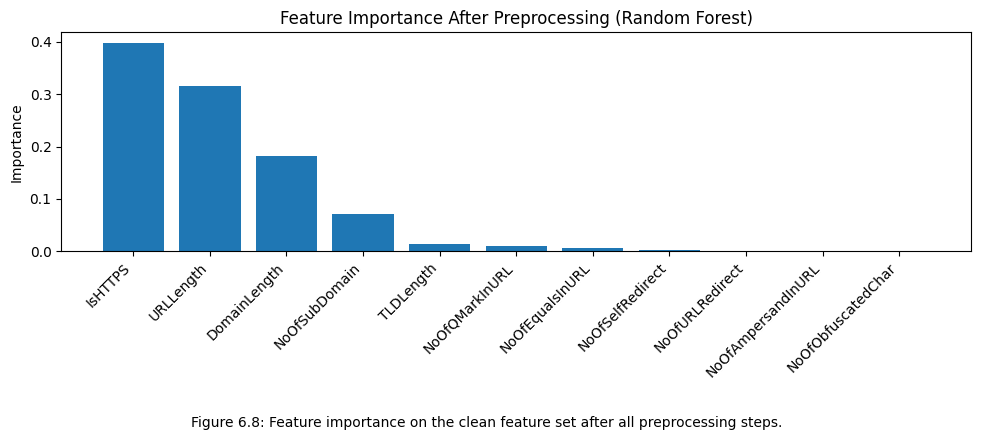

In [39]:
"""
Post-preprocessing Feature Importance (Random Forest)

Purpose:
- Re-rank features by importance using only the features that survived
  all preprocessing steps (leakage removal, content removal, ratio removal,
  correlation filtering).
- This gives a clean picture of which signals the model will actually use,
  free from the distortion caused by leaking and content features.

Inputs:
- X_train: training feature DataFrame after all removal steps.
- y_train: training target Series.

Outputs:
- Ranked importance table and bar chart.
"""

# 1) Train RF on the clean training set
rf_clean = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_clean.fit(X_train, y_train)

# 2) Compute and sort importances
clean_importances = pd.Series(
    rf_clean.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

# 3) Ranked table
clean_table = clean_importances.reset_index()
clean_table.columns = ["Feature", "Importance"]
clean_table.insert(0, "Rank", range(1, len(clean_table) + 1))
display(clean_table)

# 4) Bar chart
plt.figure(figsize=(10, 4))
plt.bar(clean_importances.index.astype(str), clean_importances.values)
plt.xticks(rotation=45, ha="right")
plt.title("Feature Importance After Preprocessing (Random Forest)")
plt.ylabel("Importance")
plt.tight_layout()
plt.figtext(
    0.5, -0.08,
    "Figure 6.8: Feature importance on the clean feature set after all preprocessing steps.",
    ha="center", fontsize=10
)
plt.show()

This importance plot reflects the features the model will actually train on
after leaking features, page-content features, redundant ratios, and correlated
features have all been removed. Unlike Figure 5.7, which was distorted by
URLSimilarityIndex and the content features, this ranking shows genuine signal
only. IsHTTPS is expected to rank highly given the dataset's sampling
characteristics discussed in Section 5.6.2.1. The remaining features reflect
lexical URL structure signals that are available at classification time.

### 6.9 Feature Scaling (Min-Max Normalization)

In [40]:
# Initialize MinMaxScaler to normalize features to the range [0, 1]
scaler = MinMaxScaler()

# Fit scaler on training data and transform training data
X_train_scaled = scaler.fit_transform(X_train)    # learn min/max from train only

# Transform test data using the same fitted scaler
X_test_scaled = scaler.transform(X_test)

# Transform validation data using the same fitted scaler
X_val_scaled = scaler.transform(X_val)

# Print resulting shapes
print("Scaled train shape:", X_train_scaled.shape)
print("Scaled test shape:", X_test_scaled.shape)
print("Scaled val shape: ", X_val_scaled.shape)

Scaled train shape: (165049, 11)
Scaled test shape: (35370, 11)
Scaled val shape:  (35376, 11)


Feature scaling is the process of adjusting the range of feature values so that they are on a similar scale. Here, we use MinMaxScaler, which transforms each feature to a fixed range between 0 and 1 using the formula: X_scaled = (X - X_min) / (X_max - X_min). This is also called Min-Max normalization.

For example, if `URLLength` originally ranges from 13 to 6,097, after Min-Max scaling it will range from 0 to 1, where 13 maps to 0 and 6,097 maps to 1. This approach is consistent with recent research on the PhiUSIIL dataset, where Min-Max normalization was used as the preprocessing step before training classification models.

The scaler is fitted only on the training data (it learns the minimum and maximum values from training data) and then the same learned parameters are applied to the test and validation data. This prevents data leakage, because if we fitted the scaler on all data, the model would indirectly have information about the test set.

Min-Max normalization is preferred here over standardization (z-score) because it preserves the original distribution shape of the features while bringing all values into a bounded [0, 1] range, which is particularly suitable for tree-based models like Random Forest and neural network-based models like FCNN that benefit from bounded input ranges.

# 7. Preprocessed Dataset Ready for Modeling

In [41]:
# Convert scaled training data back to DataFrame with column names
train_out = pd.DataFrame(X_train_scaled, columns=X_train.columns)

# Add target column to training data
train_out[target_column] = y_train.reset_index(drop=True)

# Convert scaled test data back to DataFrame with column names
test_out = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# Add target column to test data
test_out[target_column] = y_test.reset_index(drop=True)

# Convert scaled validation data back to DataFrame with column names
val_out = pd.DataFrame(X_val_scaled, columns=X_val.columns)

# Add target column to validation data
val_out[target_column] = y_val.reset_index(drop=True)

# Print final shapes
print("Final training dataset shape:", train_out.shape)
print("Final test dataset shape:", test_out.shape)
print("Final validation dataset shape:", val_out.shape)

# Display first few rows of training data
train_out.head()

Final training dataset shape: (165049, 12)
Final test dataset shape: (35370, 12)
Final validation dataset shape: (35376, 12)


,URLLength,DomainLength,TLDLength,NoOfSubDomain,NoOfObfuscatedChar,NoOfEqualsInURL,NoOfQMarkInURL,NoOfAmpersandInURL,IsHTTPS,NoOfURLRedirect,NoOfSelfRedirect,label
0,0.002595,0.160377,0.090909,0.1,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1
1,0.007265,0.424528,0.090909,0.2,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0
2,0.002076,0.141509,0.090909,0.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,0.000865,0.066038,0.000000,0.1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1
4,0.002595,0.160377,0.090909,0.1,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1


We convert the scaled NumPy arrays back into Pandas DataFrames and reattach the column names and target variable. The final training dataset has 165,049 rows and the expected number of columns (scaled features + 1 target), the test dataset has 35,370 rows, and the validation dataset has 35,376 rows.

Converting back to DataFrames with proper column names makes the data easier to work with in subsequent phases and ensures the exported CSV files have meaningful column headers.

The `.head()` output shows that all feature values now fall between 0 and 1, which confirms that the MinMaxScaler was applied correctly.

In [42]:
"""
Save preprocessed splits to CSV

Purpose:
- Export all preprocessed splits as CSV files for use by the modeling team.
- Files are saved to Colab local storage; download from the file browser (left panel).

Inputs:
- train_out, val_out, test_out: final preprocessed DataFrames.

Outputs:
- Four CSV files saved to /content/:
    preprocessed_PhiUSIIL_Phishing_URL_Dataset.csv  (train + val + test combined)
    train_preprocessed_PhiUSIIL_Phishing_URL_Dataset.csv
    val_preprocessed_PhiUSIIL_Phishing_URL_Dataset.csv
    test_preprocessed_PhiUSIIL_Phishing_URL_Dataset.csv
"""

# 1) Combine train, test and val into one full preprocessed dataset
preprocessed = pd.concat([train_out, val_out, test_out], axis=0).reset_index(drop=True)

# 2) Save all splits to Colab local storage
preprocessed.to_csv("preprocessed_PhiUSIIL_Phishing_URL_Dataset.csv", index=False)
train_out.to_csv("train_preprocessed_PhiUSIIL_Phishing_URL_Dataset.csv", index=False)
val_out.to_csv("val_preprocessed_PhiUSIIL_Phishing_URL_Dataset.csv", index=False)
test_out.to_csv("test_preprocessed_PhiUSIIL_Phishing_URL_Dataset.csv", index=False)

print(f"Saved: preprocessed   ({preprocessed.shape[0]:,} rows x {preprocessed.shape[1]} columns)")
print(f"Saved: train          ({train_out.shape[0]:,} rows x {train_out.shape[1]} columns)")
print(f"Saved: val            ({val_out.shape[0]:,} rows x {val_out.shape[1]} columns)")
print(f"Saved: test           ({test_out.shape[0]:,} rows x {test_out.shape[1]} columns)")
print("\nNote: Download from the Colab file browser (left panel) to save permanently.")


Saved: preprocessed   (235,795 rows x 12 columns)
Saved: train          (165,049 rows x 12 columns)
Saved: val            (35,376 rows x 12 columns)
Saved: test           (35,370 rows x 12 columns)

Note: Download from the Colab file browser (left panel) to save permanently.


We combine the preprocessed training and test DataFrames into a single full dataset and save all four splits as CSV files to Colab's local storage (`/content/`). Files can be downloaded from the file browser in the left panel.
Note that Colab's local storage is temporary files will be lost when the session ends, so download them after running this cell.

In [43]:
"""
Save fitted scaler for reuse

Purpose:
- Export the fitted MinMaxScaler object so it can be loaded in the modeling
  phase to apply the same scaling to new data without refitting.

Inputs:
- scaler: MinMaxScaler fitted on training data.

Outputs:
- phishing_scaler.pkl saved to /content/.
"""

# Save the fitted scaler to Colab local storage
joblib.dump(scaler, "/content/phishing_scaler.pkl")

print("Saved: /content/phishing_scaler.pkl")
print("Download from the Colab file browser (left panel) before the session ends.")

Saved: /content/phishing_scaler.pkl
Download from the Colab file browser (left panel) before the session ends.


We save the fitted MinMaxScaler using `joblib` so it can be reloaded in the modeling phase. This ensures that new or unseen data is scaled using the exact same min/max values learned from the training set, preventing any inconsistency between preprocessing and prediction.

The file is saved to Colab's local storage (`/content/`), which is temporary. Download it from the file browser in the left panel before the session ends.

# 8. Key Insights and Challenges

**Key Insights:**

1. The dataset contains 235,795 URL samples, 54 original input columns, and a binary target variable (1 = legitimate, 0 = phishing). After excluding non-numeric identifier/text columns, 50 numeric features remained before preprocessing.

2. The dataset is clean with no missing values or duplicate rows, which simplified preprocessing and eliminated the need for imputation.

3. The class distribution is mildly imbalanced (57.2% legitimate, 42.8% phishing), which is manageable with stratified splitting and standard evaluation metrics.

4. The First Contact audit identified three tiers of features: lexical/URL-string features, DNS/WHOIS features, and page-content features that require downloading the page and cannot be observed before the page loads.

5. The strongest genuine lexical predictors are `IsHTTPS` (0.61 correlation with target) and character-level URL metrics. Page-content signals like `HasSocialNet` (0.78) and `HasCopyrightInfo` (0.74) are strong but require page download and are therefore removed, as they are not observable before the page loads.


6. `IsHTTPS` is retained as a genuine, zero-cost lexical signal but carries a dataset-level caveat: legitimate URLs in PhiUSIIL were sourced from top-ranked domains that are uniformly HTTPS, making it a near-perfect separator in this dataset. In the real world its discriminative power is weaker. This is the primary driver of the 100% accuracy observed in the supervised learning phase and is acknowledged as a dataset limitation rather than a modeling error.

7. Features fall into complementary groups: URL structure features (e.g., `URLLength`, `NoOfDegitsInURL`) and lexical security signals (e.g., `IsHTTPS`, `IsDomainIP`). Both groups carry independent phishing signals without requiring page download.

8. Multiple rounds of feature elimination were applied during preprocessing:
   - Six label-leaking features removed (Section 6.3) encoded ground-truth label information.
   - 24 page-content features removed (Section 6.3.1) require page download and are therefore removed.
   - Four redundant ratio features removed (Section 6.4) duplicated their count counterparts.
   - Highly correlated features removed at a 0.80 threshold (Section 6.7) iterative, train-only.
   - Near-constant low-variance features removed (Section 6.8).

9. Several count-based features (e.g., `URLLength`, `NoOfDegitsInURL`) contain notable high-value outliers. These were retained as they may represent meaningful structural differences between phishing and legitimate pages.

---

**Challenges:**

1. **Label leakage in the published dataset**: six features were derived from ground-truth label information during dataset construction. Including them produces ~100% accuracy that does not generalize. Identifying and removing them required understanding the dataset's construction methodology.

2. **Dataset sampling bias in `IsHTTPS`**: legitimate URLs were sourced exclusively from top-ranked domains that are uniformly HTTPS, making `IsHTTPS` a near-perfect separator in this dataset. This is a sampling artifact the feature is genuinely valid, but the dataset overstates its discriminative power. The result is near-perfect model accuracy that reflects the dataset's composition rather than a generalizable phishing detection rule. This is documented and retained as a known limitation rather than corrected by dropping the feature.

3. **Redundant feature pairs**: count-ratio pairs encode identical information at different scales. Identified in EDA (Section 5.5.2) and removed in preprocessing (Section 6.4).

4. **Skewed distributions**: several count-based features show strong positive skewness. MinMaxScaler normalizes scale but does not correct skewness, which may affect distance-based or linear models.

5. **Feature dimensionality**: aggressive but justified feature elimination was necessary to ensure the model learns from genuinely independent and informative signals. Each removal step is backed by a specific EDA finding.

6. **Mild class imbalance**: the 57/43 split is not severe, but evaluation metrics beyond accuracy (Precision, Recall, F1, ROC-AUC) should be used to ensure neither class is systematically misclassified.